# 🛒 Team Daffodils — Group 4
# Online Shoppers Purchasing Intention: EDA & Statistical Analysis

**Dataset:** 12,205 sessions · 19 features · Target: `Revenue` (1 = Purchase, 0 = No Purchase)

---

This notebook combines two parts:

- **Part A — Exploratory Data Analysis & Visualisation** — distributions, patterns, and behavioural insights
- **Part B — Statistical Analysis** — hypothesis testing, effect sizes, feature importance, and multicollinearity

---

### Colour System
| Colour | Hex | Meaning |
|--------|-----|---------|
| 🟦 Dark Navy | `#1a3a5c` | Purchase / significant / action taken |
| 🔹 Light Blue | `#a8c8e8` | No Purchase / acceptable / no action |
| 🔴 Dark Red | `#c00000` | Warning — needs attention |
| ⬜ Mid Blue | `#2e75b6` | Single-series neutral charts |
| ▫️ Grey dashed | `grey` | Volume / context reference |

---
# PART A — Exploratory Data Analysis & Visualisation

## 1. Setup & Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
import seaborn as sns
from scipy import stats as scipy_stats
import warnings
warnings.filterwarnings('ignore')

# ══════════════════════════════════════════════════════════
# COLOUR SYSTEM — every colour carries a deliberate meaning
# ══════════════════════════════════════════════════════════
C_YES    = '#1a3a5c'   # Dark navy  — Purchase / significant / action taken
C_NO     = '#a8c8e8'   # Light blue — No Purchase / acceptable / no action
C_SINGLE = '#2e75b6'   # Mid blue   — Single-series neutral charts
C_WARN   = '#c00000'   # Dark red   — Warning / needs attention
C_OK     = '#a8c8e8'   # Light blue — Acceptable / fine
palette  = {0: C_NO, 1: C_YES}
# ══════════════════════════════════════════════════════════

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi']     = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# ── Update this path to point at your CSV ──────────────────
DATA_PATH = r"C:\Users\User\Downloads\cleaned_online_shoppers_intention_for_viz.csv"

df = pd.read_csv(DATA_PATH)

numeric_cols = [
    'Administrative', 'Administrative_Duration',
    'Informational', 'Informational_Duration',
    'ProductRelated', 'ProductRelated_Duration',
    'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay'
]

print(f'Shape: {df.shape}')
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'Duplicates: {df.duplicated().sum()}')
print(f'\nRevenue distribution:')
print(df['Revenue'].value_counts())
df.head()

Shape: (12205, 19)
Missing values: 0
Duplicates: 0

Revenue distribution:
Revenue
0    10297
1     1908
Name: count, dtype: int64


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue,Month_Num
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,0,0,2
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,0,0,2
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,0,0,2
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,0,0,2
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,1,0,2


## 2. Descriptive Statistics

In [2]:
overall = df[numeric_cols].agg(['count','mean','median','std','min','max']).T
overall.columns = ['Count','Mean','Median','Std Dev','Min','Max']
overall['Skewness'] = df[numeric_cols].skew()
overall['Kurtosis'] = df[numeric_cols].kurt()
print('OVERALL DESCRIPTIVE STATISTICS')
print('='*90)
display(overall.round(3))

print('\nMEAN BY PURCHASE OUTCOME')
print('='*90)
display(df.groupby('Revenue')[numeric_cols].mean().round(3))

OVERALL DESCRIPTIVE STATISTICS


,Count,Mean,Median,Std Dev,Min,Max,Skewness,Kurtosis
Administrative,12205.0,2.339,1.000,3.330,0.0,27.000,1.947,4.641
Administrative_Duration,12205.0,81.646,9.000,177.492,0.0,3398.750,5.592,50.137
Informational,12205.0,0.509,0.000,1.276,0.0,24.000,4.014,26.659
Informational_Duration,12205.0,34.825,0.000,141.425,0.0,2549.375,7.540,75.534
ProductRelated,12205.0,32.046,18.000,44.594,0.0,705.000,4.333,31.073
ProductRelated_Duration,12205.0,1206.982,608.943,1919.601,0.0,63973.522,7.253,136.681
BounceRates,12205.0,0.020,0.003,0.045,0.0,0.200,3.162,9.334
ExitRates,12205.0,0.041,0.025,0.046,0.0,0.200,2.235,4.642
PageValues,12205.0,5.950,0.000,18.654,0.0,361.764,6.351,64.998
SpecialDay,12205.0,0.062,0.000,0.200,0.0,1.000,3.286,9.798



MEAN BY PURCHASE OUTCOME


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay
Revenue,,,,,,,,,,
0,2.143,74.635,0.457,30.603,29.05,1082.977,0.023,0.046,2.000,0.069
1,3.394,119.483,0.786,57.611,48.21,1876.210,0.005,0.020,27.265,0.023


## 3. Class Balance : Who Actually Buys?

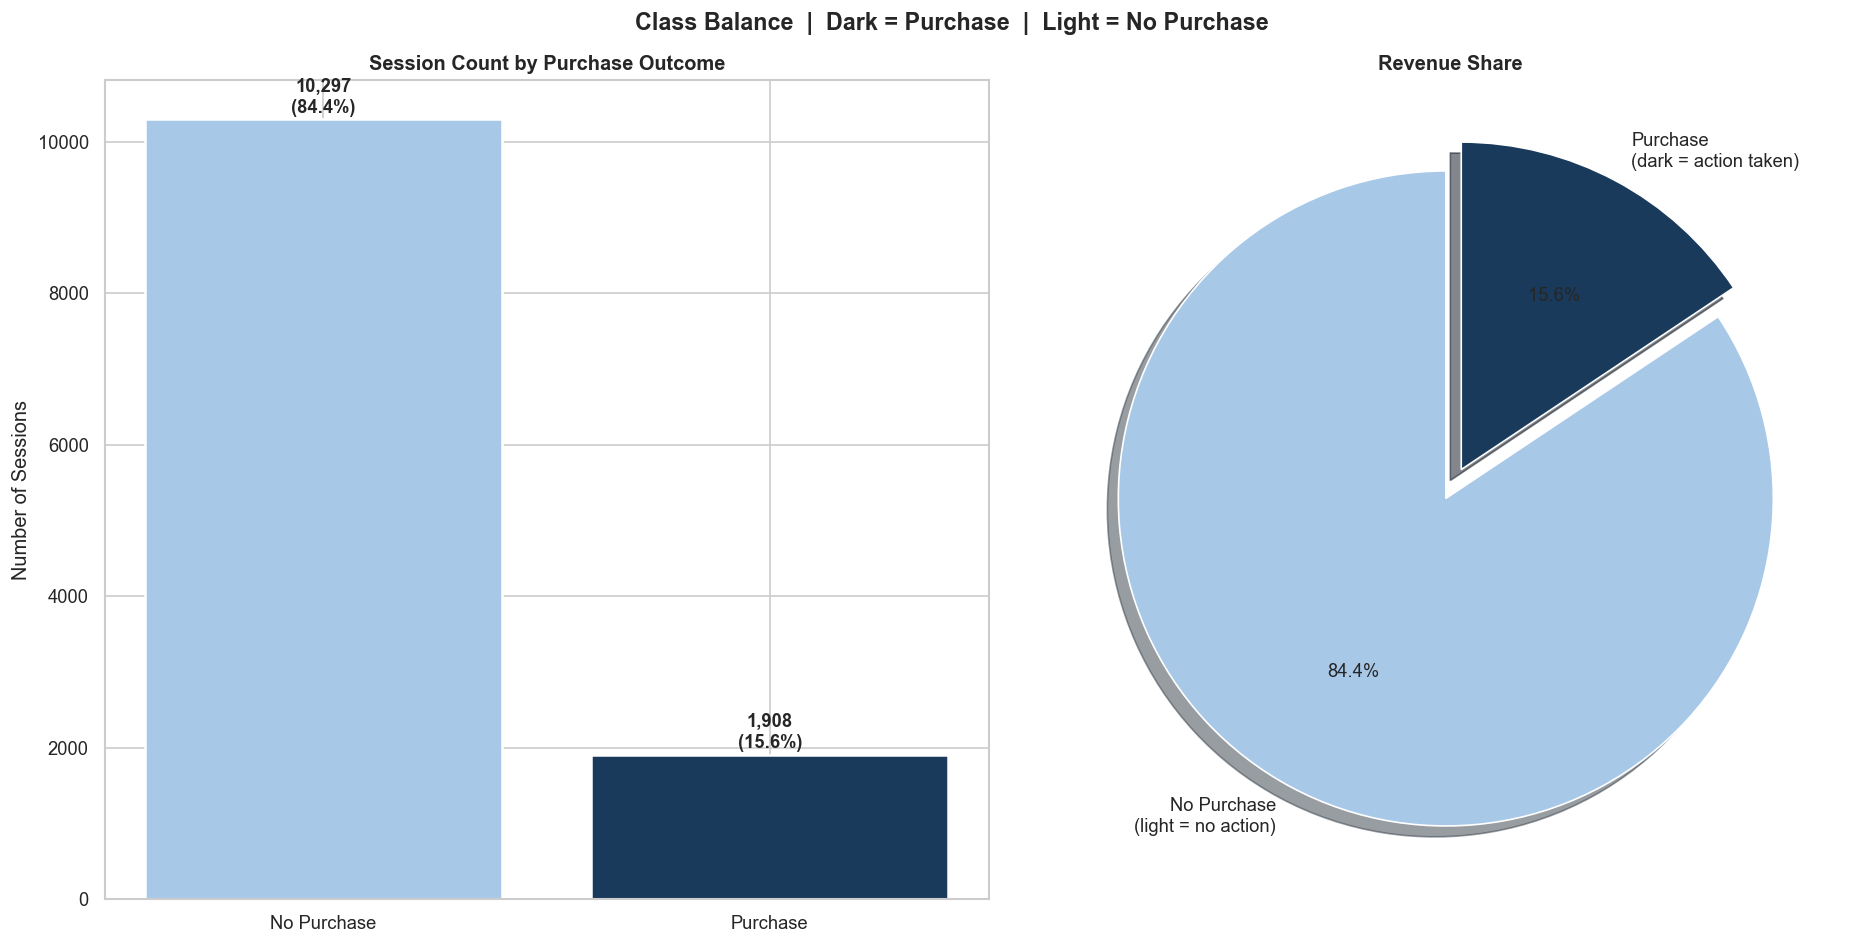

Imbalance ratio: 5.4:1  (Non-purchase to Purchase)
A naive model always predicting No Purchase = 84.4% accuracy — misleading!
→ Use F1-Score, AUC-ROC and Precision-Recall for evaluation.


In [52]:
# COLOUR MEANING: Dark navy = Purchase | Light blue = No Purchase
counts = df['Revenue'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Bar chart
bars = axes[0].bar(['No Purchase', 'Purchase'], counts.values,
                   color=[C_NO, C_YES], edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+90,
                 f'{v:,}\n({v/counts.sum()*100:.1f}%)',
                 ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Session Count by Purchase Outcome', fontweight='bold')
axes[0].set_ylabel('Number of Sessions')

# Pie chart
axes[1].pie(counts.values,
            labels=['No Purchase\n(light = no action)', 'Purchase\n(dark = action taken)'],
            autopct='%1.1f%%', colors=[C_NO, C_YES],
            explode=(0.03, 0.07), shadow=True, startangle=90,
            textprops={'fontsize': 11})
axes[1].set_title('Revenue Share', fontweight='bold')

plt.suptitle('Class Balance  |  Dark = Purchase  |  Light = No Purchase',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

ratio = counts[0] / counts[1]
print(f'Imbalance ratio: {ratio:.1f}:1  (Non-purchase to Purchase)')
print(f'A naive model always predicting No Purchase = {counts[0]/counts.sum()*100:.1f}% accuracy — misleading!')
print('→ Use F1-Score, AUC-ROC and Precision-Recall for evaluation.')

> **Insight:** The dataset is heavily imbalanced : **84.4% of sessions result in no purchase** and only **15.6% lead to a purchase**.  
> A model predicting "No Purchase" every time would still score 84.4% accuracy, use AUC-ROC and F1 instead.

## 4. Univariate Analysis: Distribution of All Features

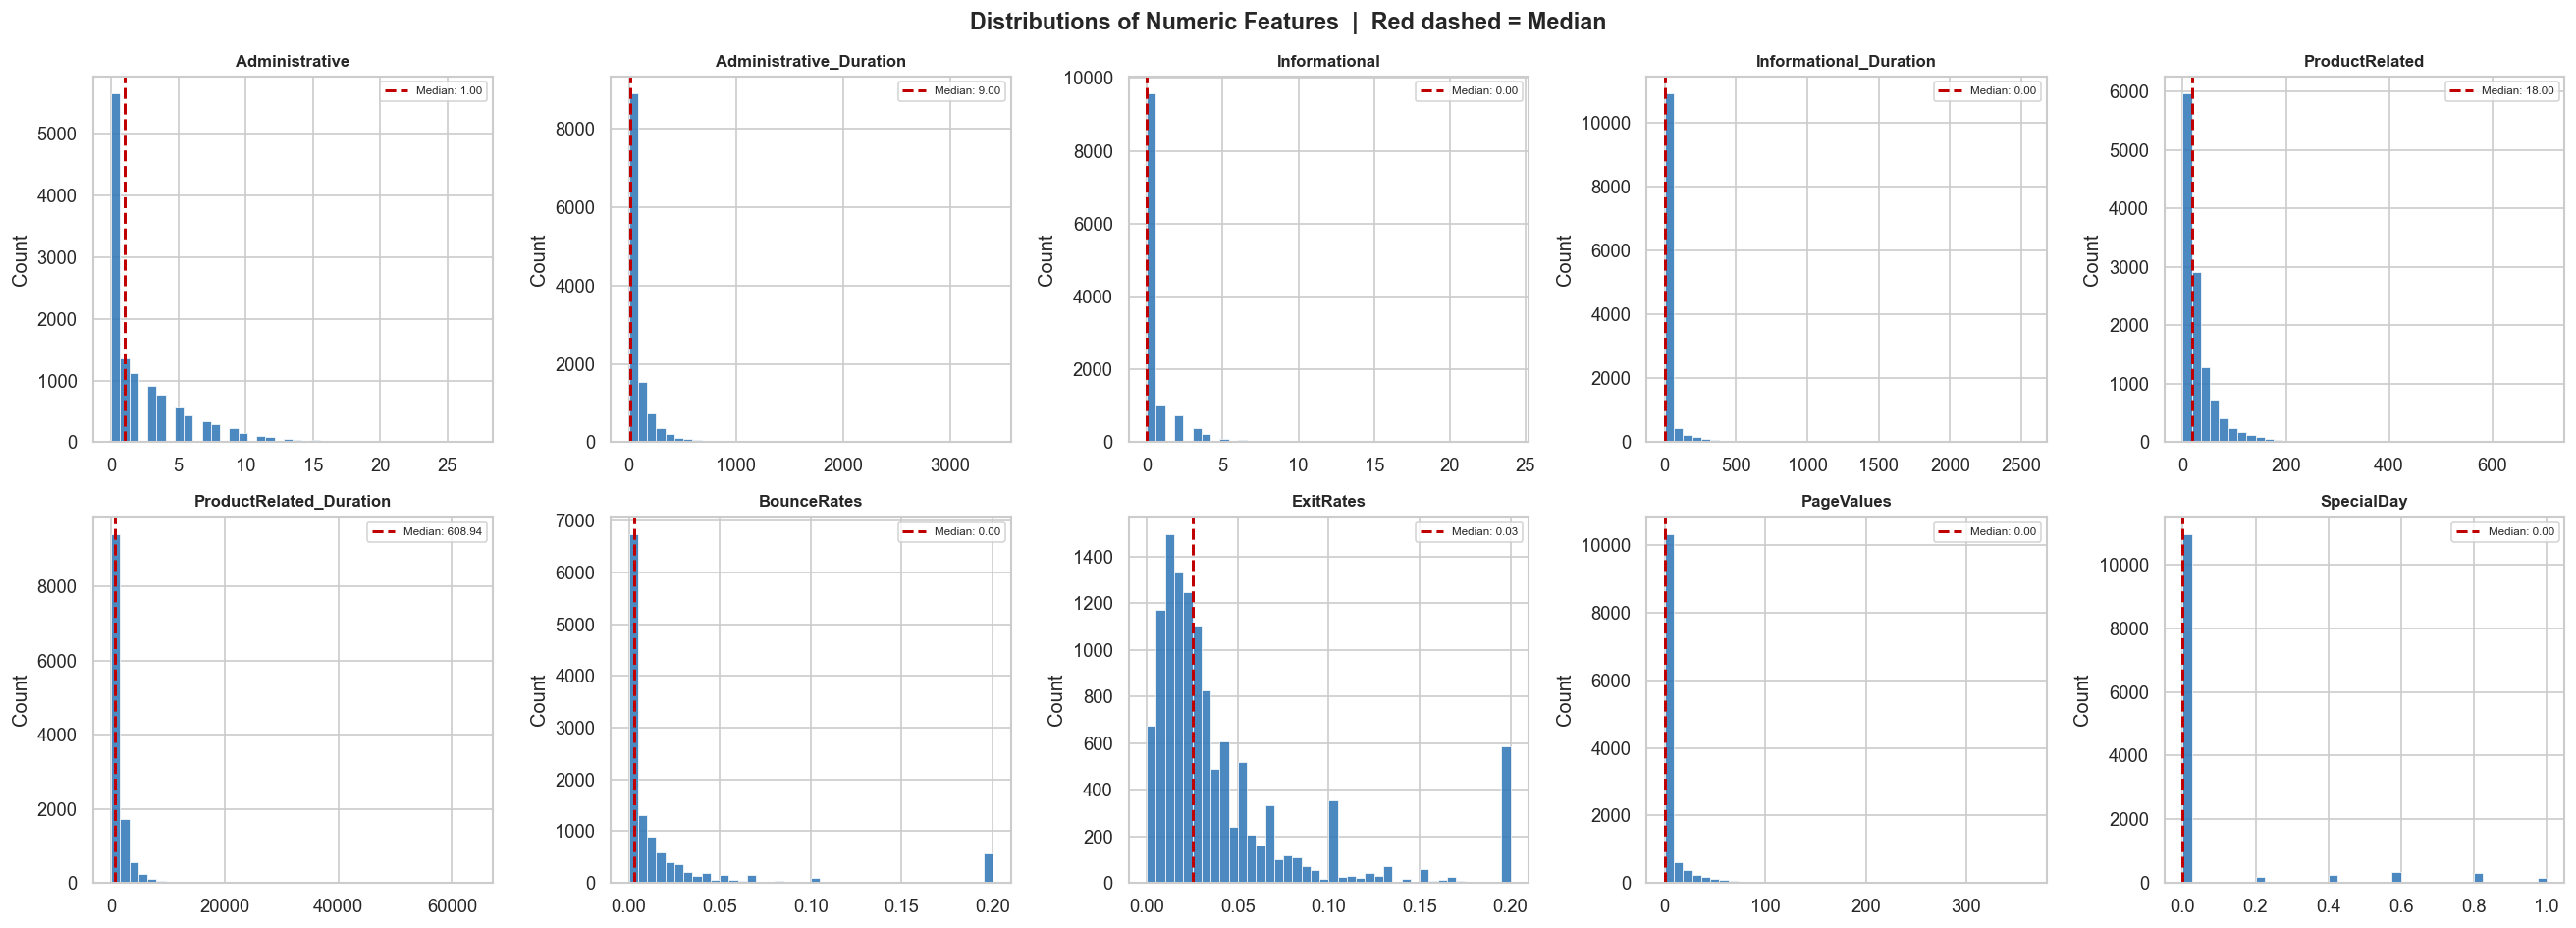

In [57]:
# COLOUR MEANING: Mid blue = single series neutral | Red dashed = median reference
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=40, color=C_SINGLE,
                 edgecolor='white', linewidth=0.5, alpha=0.85)
    median_val = df[col].median()
    axes[i].axvline(median_val, color=C_WARN, linewidth=1.8,
                    linestyle='--', label=f'Median: {median_val:.2f}')
    axes[i].legend(fontsize=7)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Count')

plt.suptitle('Distributions of Numeric Features  |  Red dashed = Median',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

> **Insight:** Every numeric feature is **heavily right-skewed** — most sessions have near-zero values with a long tail of high-engagement outliers.

## 5. Skewness & Kurtosis

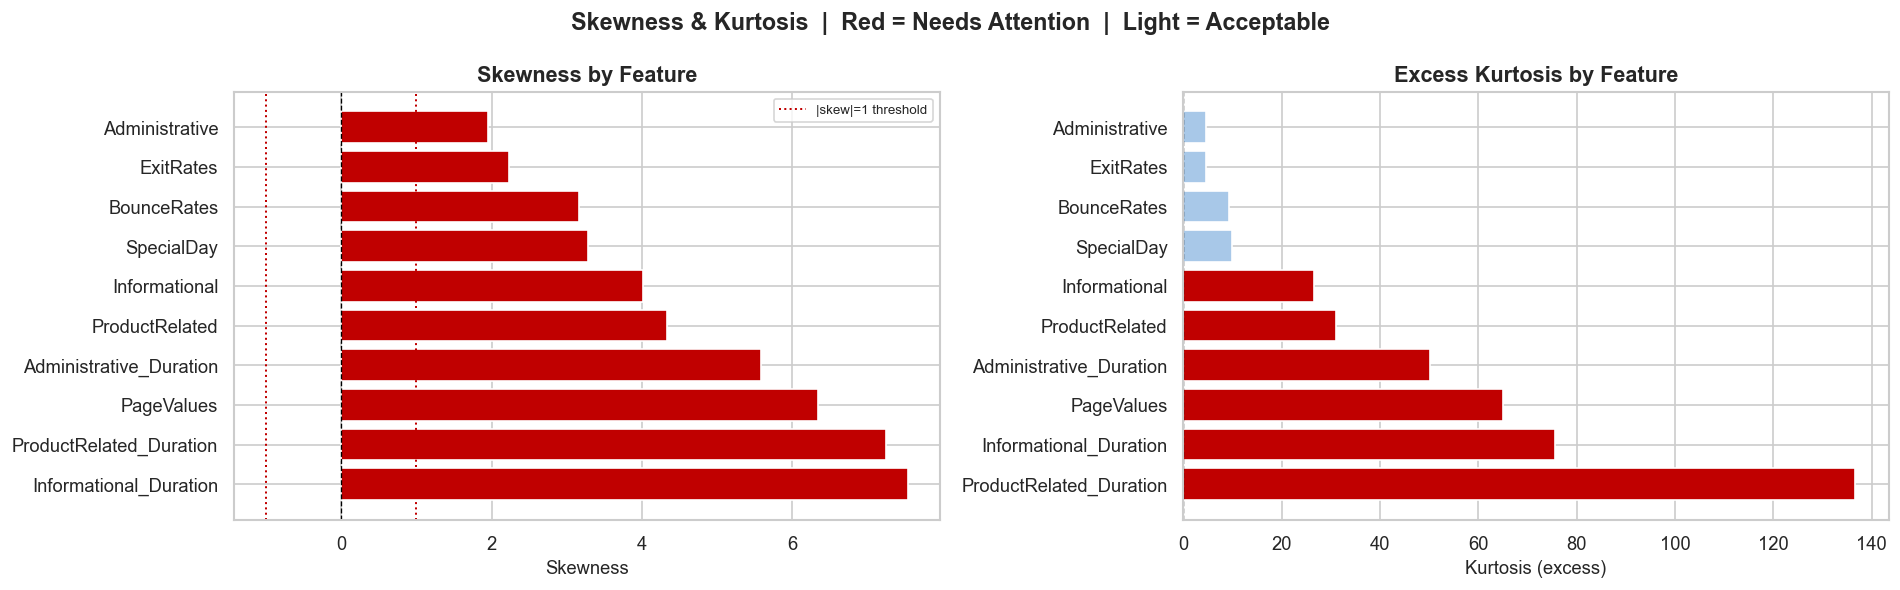

All features highly skewed (|skew|>1): ['Informational_Duration', 'ProductRelated_Duration', 'PageValues', 'Administrative_Duration', 'ProductRelated', 'Informational', 'SpecialDay', 'BounceRates', 'ExitRates', 'Administrative']
→ Apply log1p transformation before modelling.


In [5]:
# COLOUR MEANING: Dark red = highly skewed (needs fixing) | Light blue = acceptable
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sv = df[numeric_cols].skew().sort_values(ascending=False)
kv = df[numeric_cols].kurt().sort_values(ascending=False)

cs = [C_WARN if abs(v) > 1 else C_OK for v in sv]
axes[0].barh(sv.index, sv.values, color=cs, edgecolor='white')
axes[0].axvline(0,  color='black', lw=0.8, ls='--')
axes[0].axvline(1,  color=C_WARN, lw=1.2, ls=':', label='|skew|=1 threshold')
axes[0].axvline(-1, color=C_WARN, lw=1.2, ls=':')
axes[0].set_title('Skewness by Feature', fontweight='bold')
axes[0].set_xlabel('Skewness')
axes[0].legend(fontsize=8)

kc = [C_WARN if abs(v) > 10 else C_OK for v in kv]
axes[1].barh(kv.index, kv.values, color=kc, edgecolor='white')
axes[1].axvline(0, color='black', lw=0.8, ls='--')
axes[1].set_title('Excess Kurtosis by Feature', fontweight='bold')
axes[1].set_xlabel('Kurtosis (excess)')

plt.suptitle('Skewness & Kurtosis  |  Red = Needs Attention  |  Light = Acceptable',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

hs = sv[sv.abs() > 1].index.tolist()
print(f'All features highly skewed (|skew|>1): {hs}')
print('→ Apply log1p transformation before modelling.')

> **Insight:** **All 10 numeric features are highly skewed**.
> For every red bar, apply **log1p** transformation before modelling.

## 6. Bivariate Analysis: Feature Distributions by Purchase Outcome

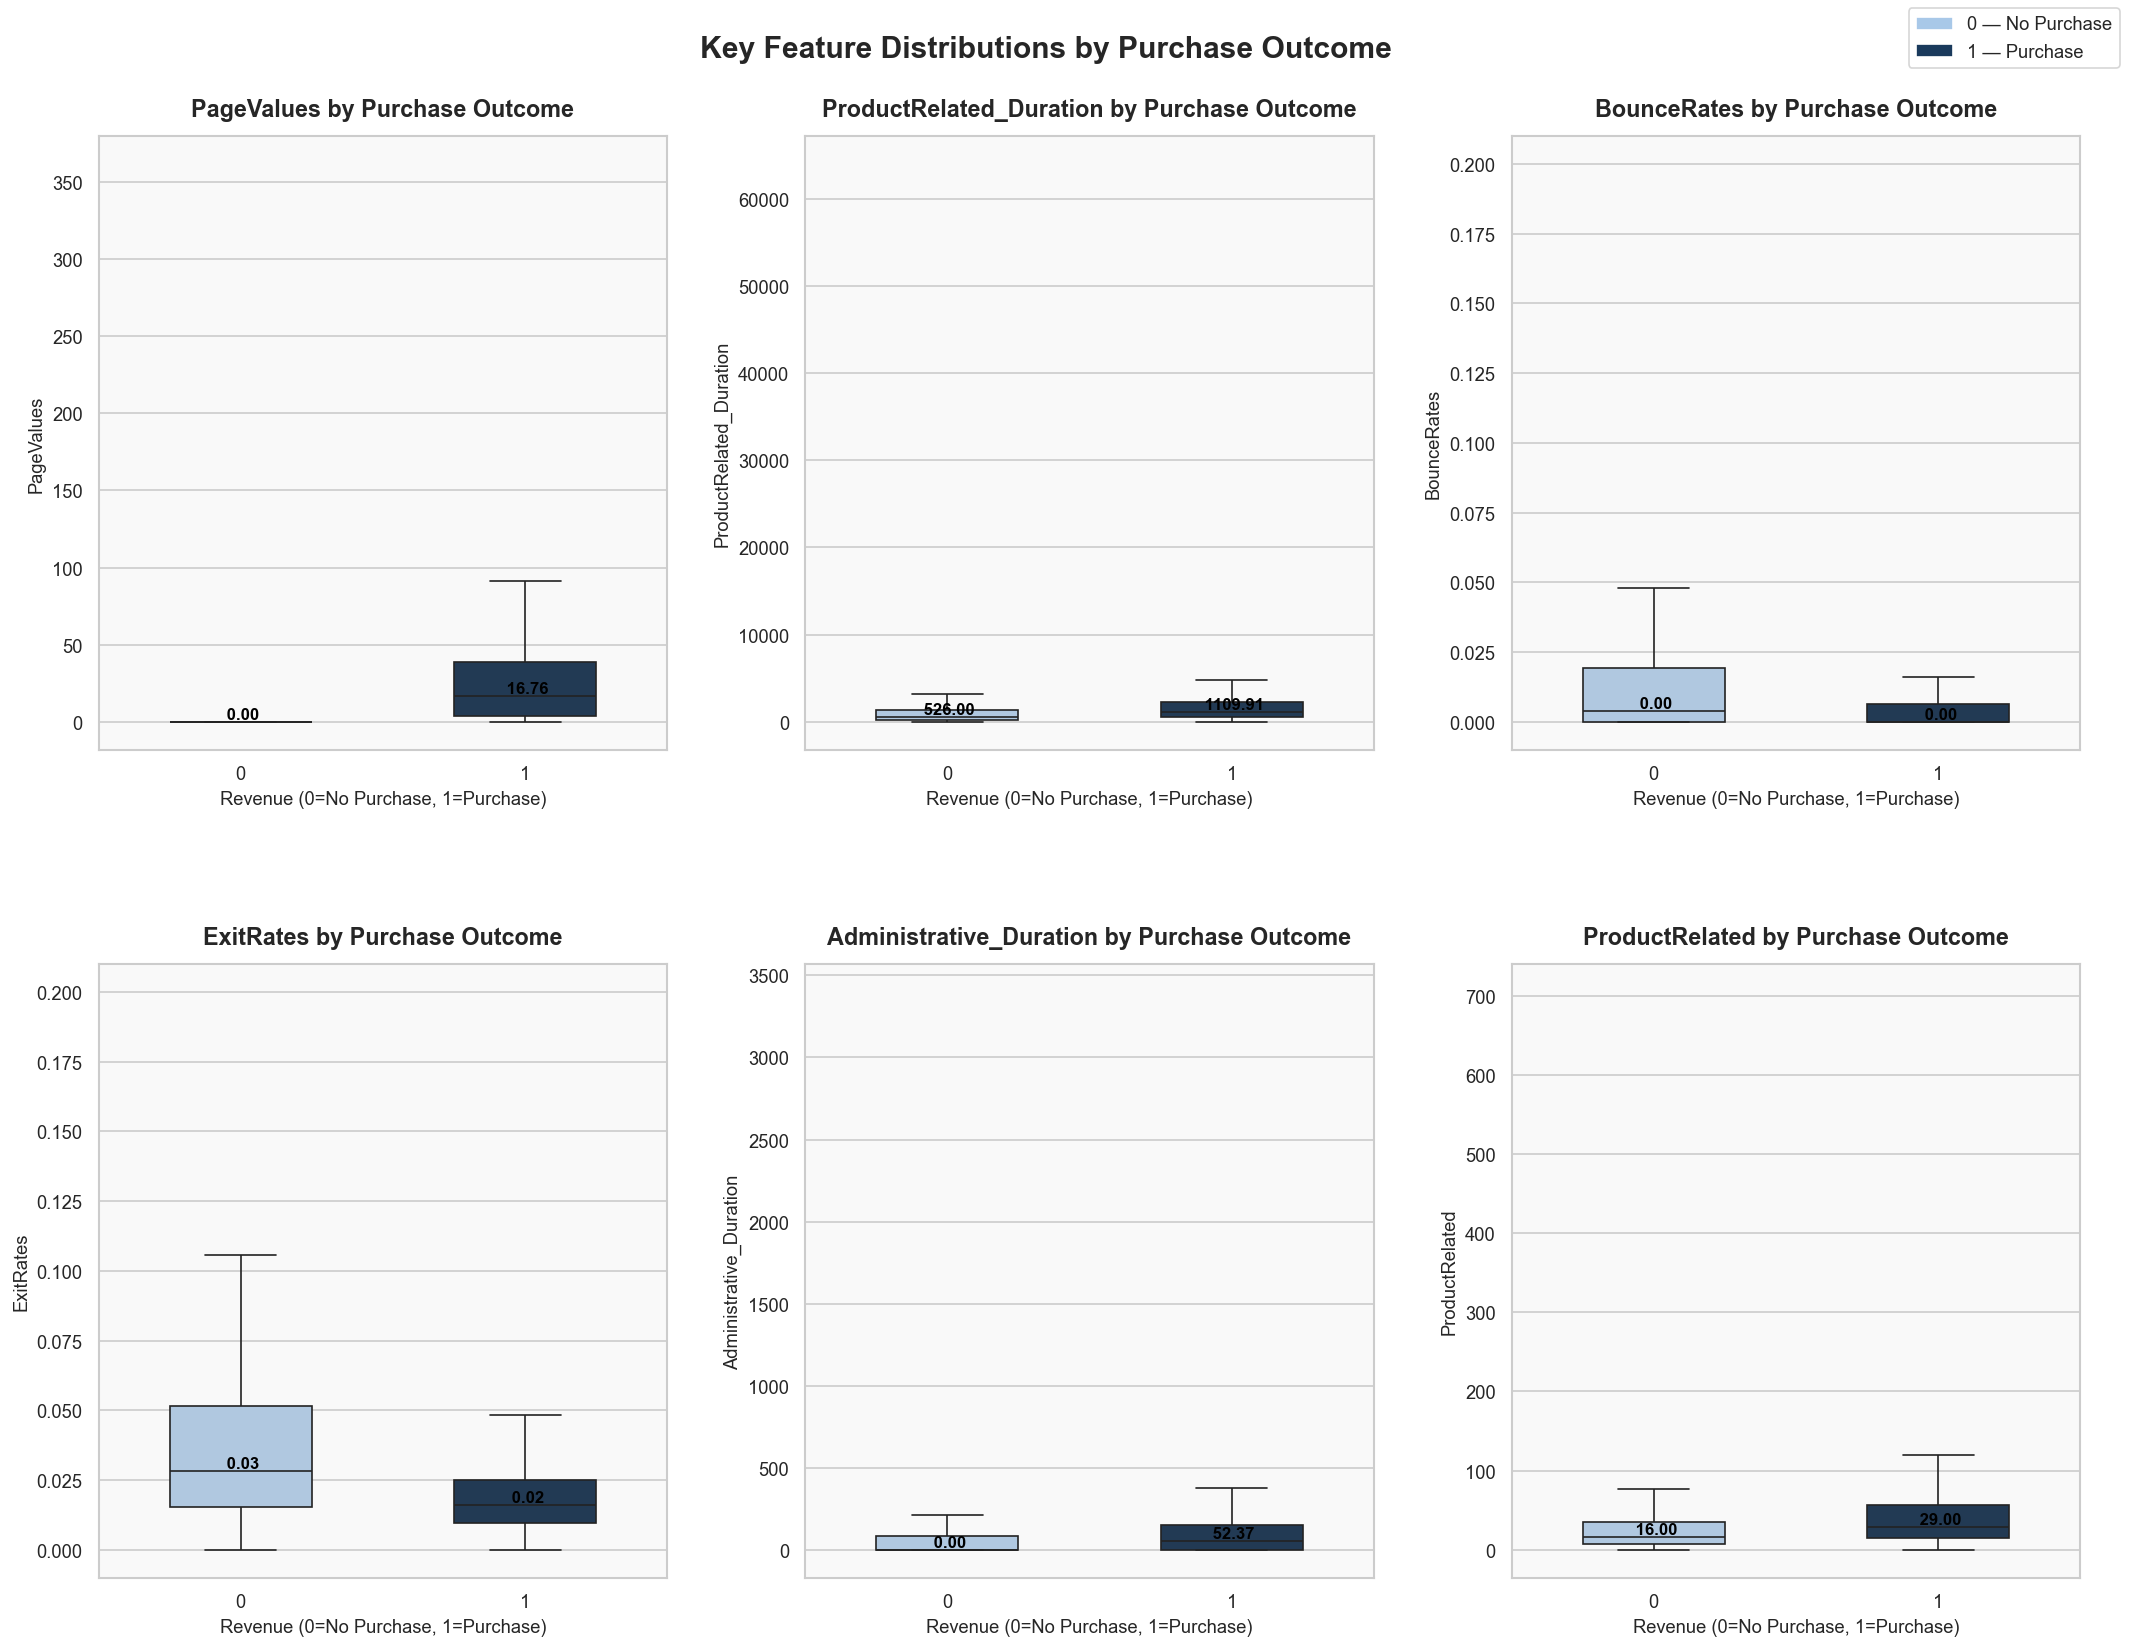

In [62]:
# COLOUR MEANING: Dark navy = Purchase | Light blue = No Purchase
# Median values labelled on each box for easy reading
key_features = ['PageValues', 'ProductRelated_Duration', 'BounceRates',
                'ExitRates', 'Administrative_Duration', 'ProductRelated']

fig, axes = plt.subplots(2, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(key_features):
    sns.boxplot(data=df, x='Revenue', y=col, ax=axes[i],
                hue='Revenue', palette=palette, legend=False,
                width=0.5, flierprops={'marker': 'none'})
    for j, rev in enumerate([0, 1]):
        median = df[df['Revenue']==rev][col].median()
        axes[i].text(j, median, f' {median:.2f}',
                     va='bottom', ha='center', fontsize=10,
                     fontweight='bold', color='black')
    axes[i].set_title(f'{col} by Purchase Outcome', fontsize=14, fontweight='bold', pad=12)
    axes[i].set_xlabel('Revenue (0=No Purchase, 1=Purchase)', fontsize=11)
    axes[i].set_ylabel(col, fontsize=11)
    axes[i].set_facecolor('#f9f9f9')

legend_els = [Patch(facecolor=C_NO,  label='0 — No Purchase'),
              Patch(facecolor=C_YES, label='1 — Purchase')]
fig.legend(handles=legend_els, loc='upper right', fontsize=11)
plt.suptitle('Key Feature Distributions by Purchase Outcome',
             fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout(pad=2.5)
plt.subplots_adjust(top=0.92, hspace=0.35)
plt.show()

> **Insight:** Clear differences exist across all six features. **PageValues** shows the most dramatic gap.

> Median jumps from 0 (non-buyers) to a much higher value for buyers.

## 7. Split Histograms: Buyer vs Non-Buyer Distributions

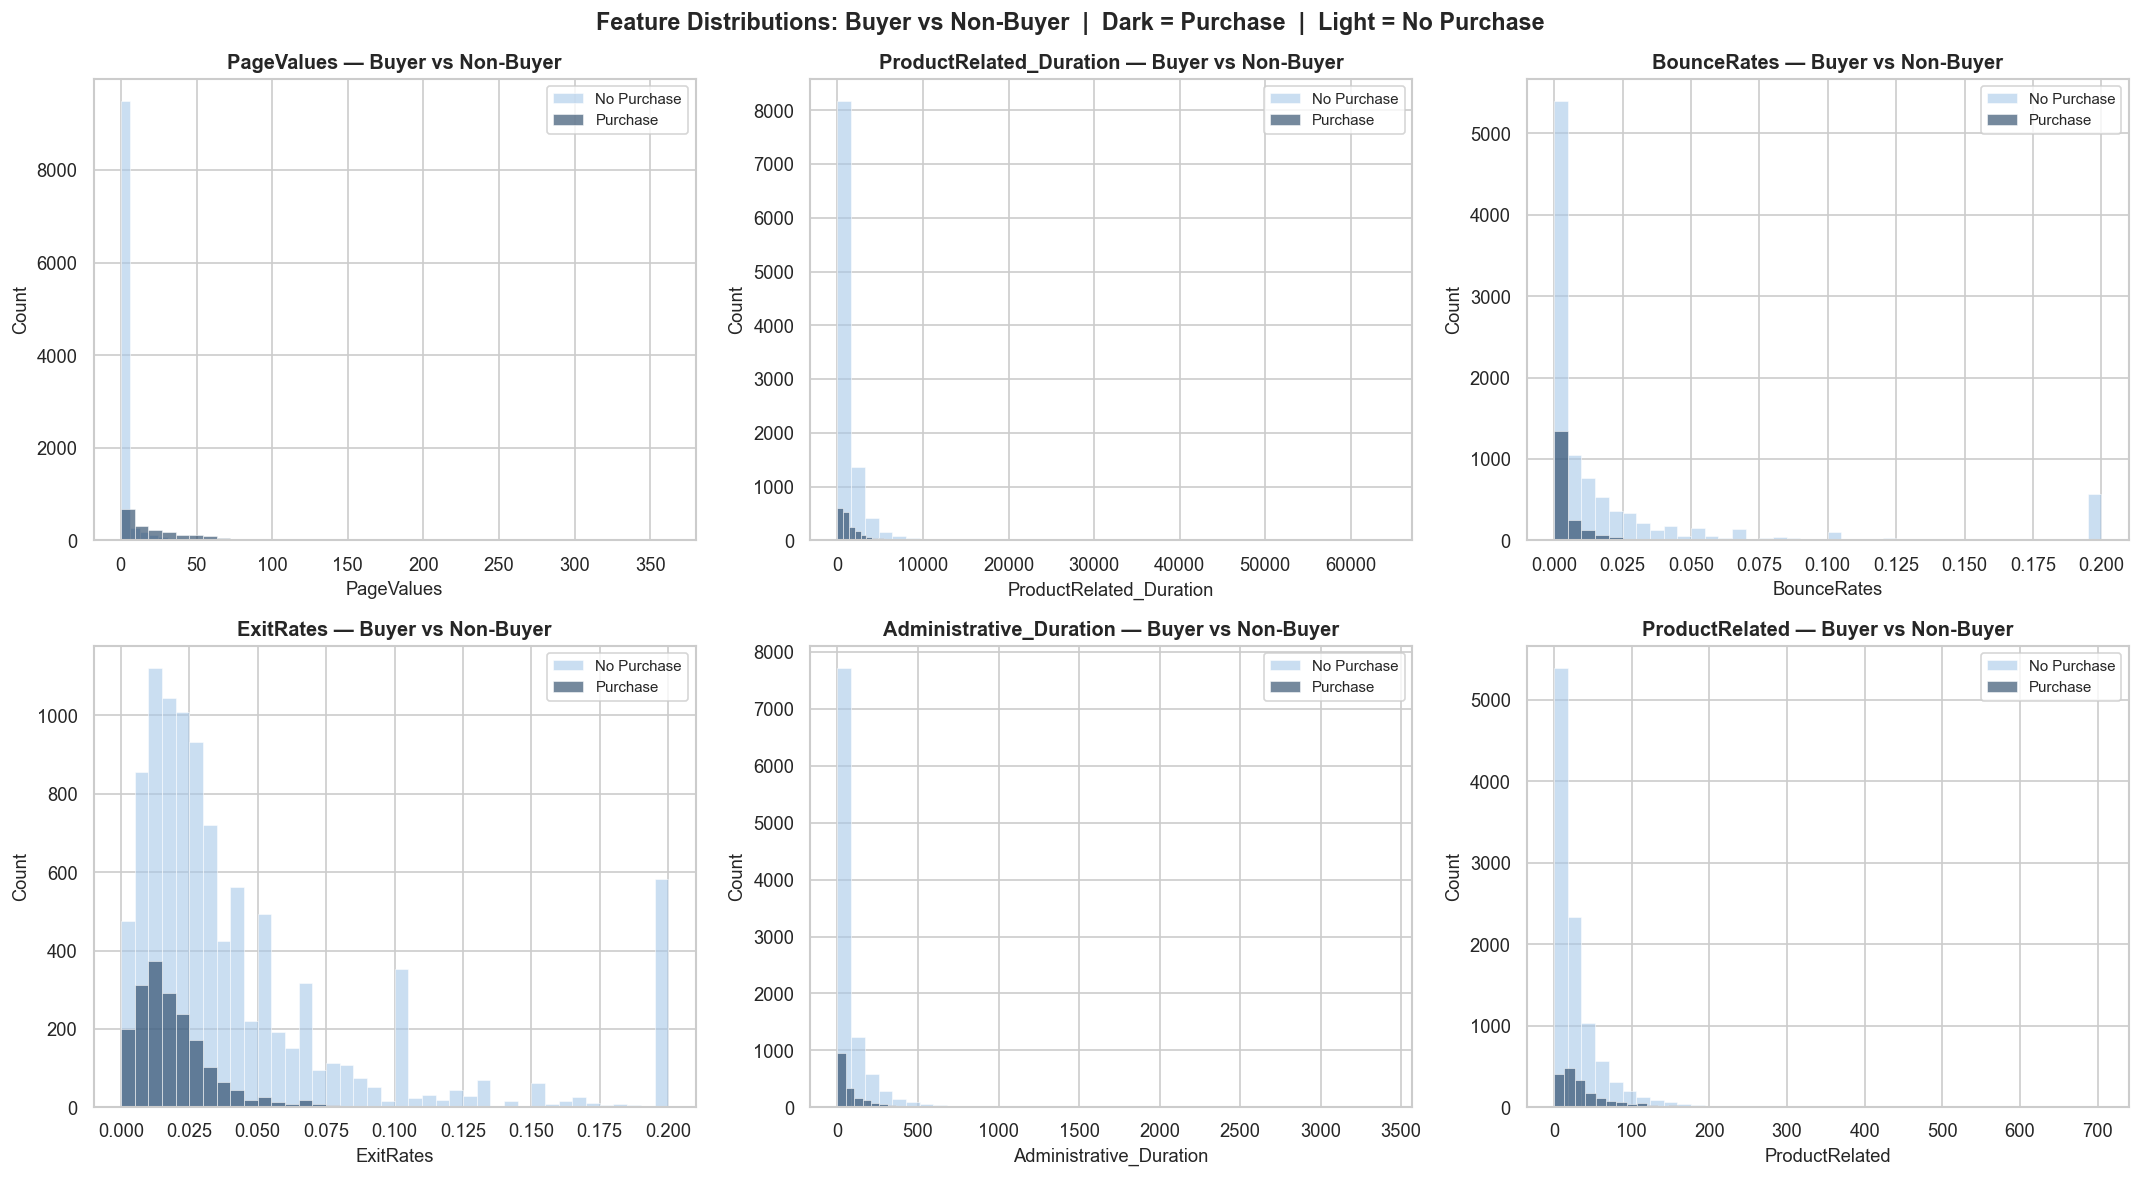

In [7]:
# COLOUR MEANING: Dark navy = Purchase | Light blue = No Purchase
# Overlapping histograms show where distributions diverge
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(key_features):
    for rev, color, name in zip([0, 1], [C_NO, C_YES], ['No Purchase', 'Purchase']):
        subset = df[df['Revenue']==rev][col]
        axes[i].hist(subset, bins=40, alpha=0.6, color=color,
                     label=name, edgecolor='white', linewidth=0.5)
    axes[i].set_title(f'{col} — Buyer vs Non-Buyer', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=9)

plt.suptitle('Feature Distributions: Buyer vs Non-Buyer  |  Dark = Purchase  |  Light = No Purchase',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

> **Insight:** For most features, both groups concentrate near zero. The key difference is that **buyers have a longer and heavier tail**: meaning a subset of buyers are highly engaged.

## 8. Mean ± Std Comparison by Purchase Outcome

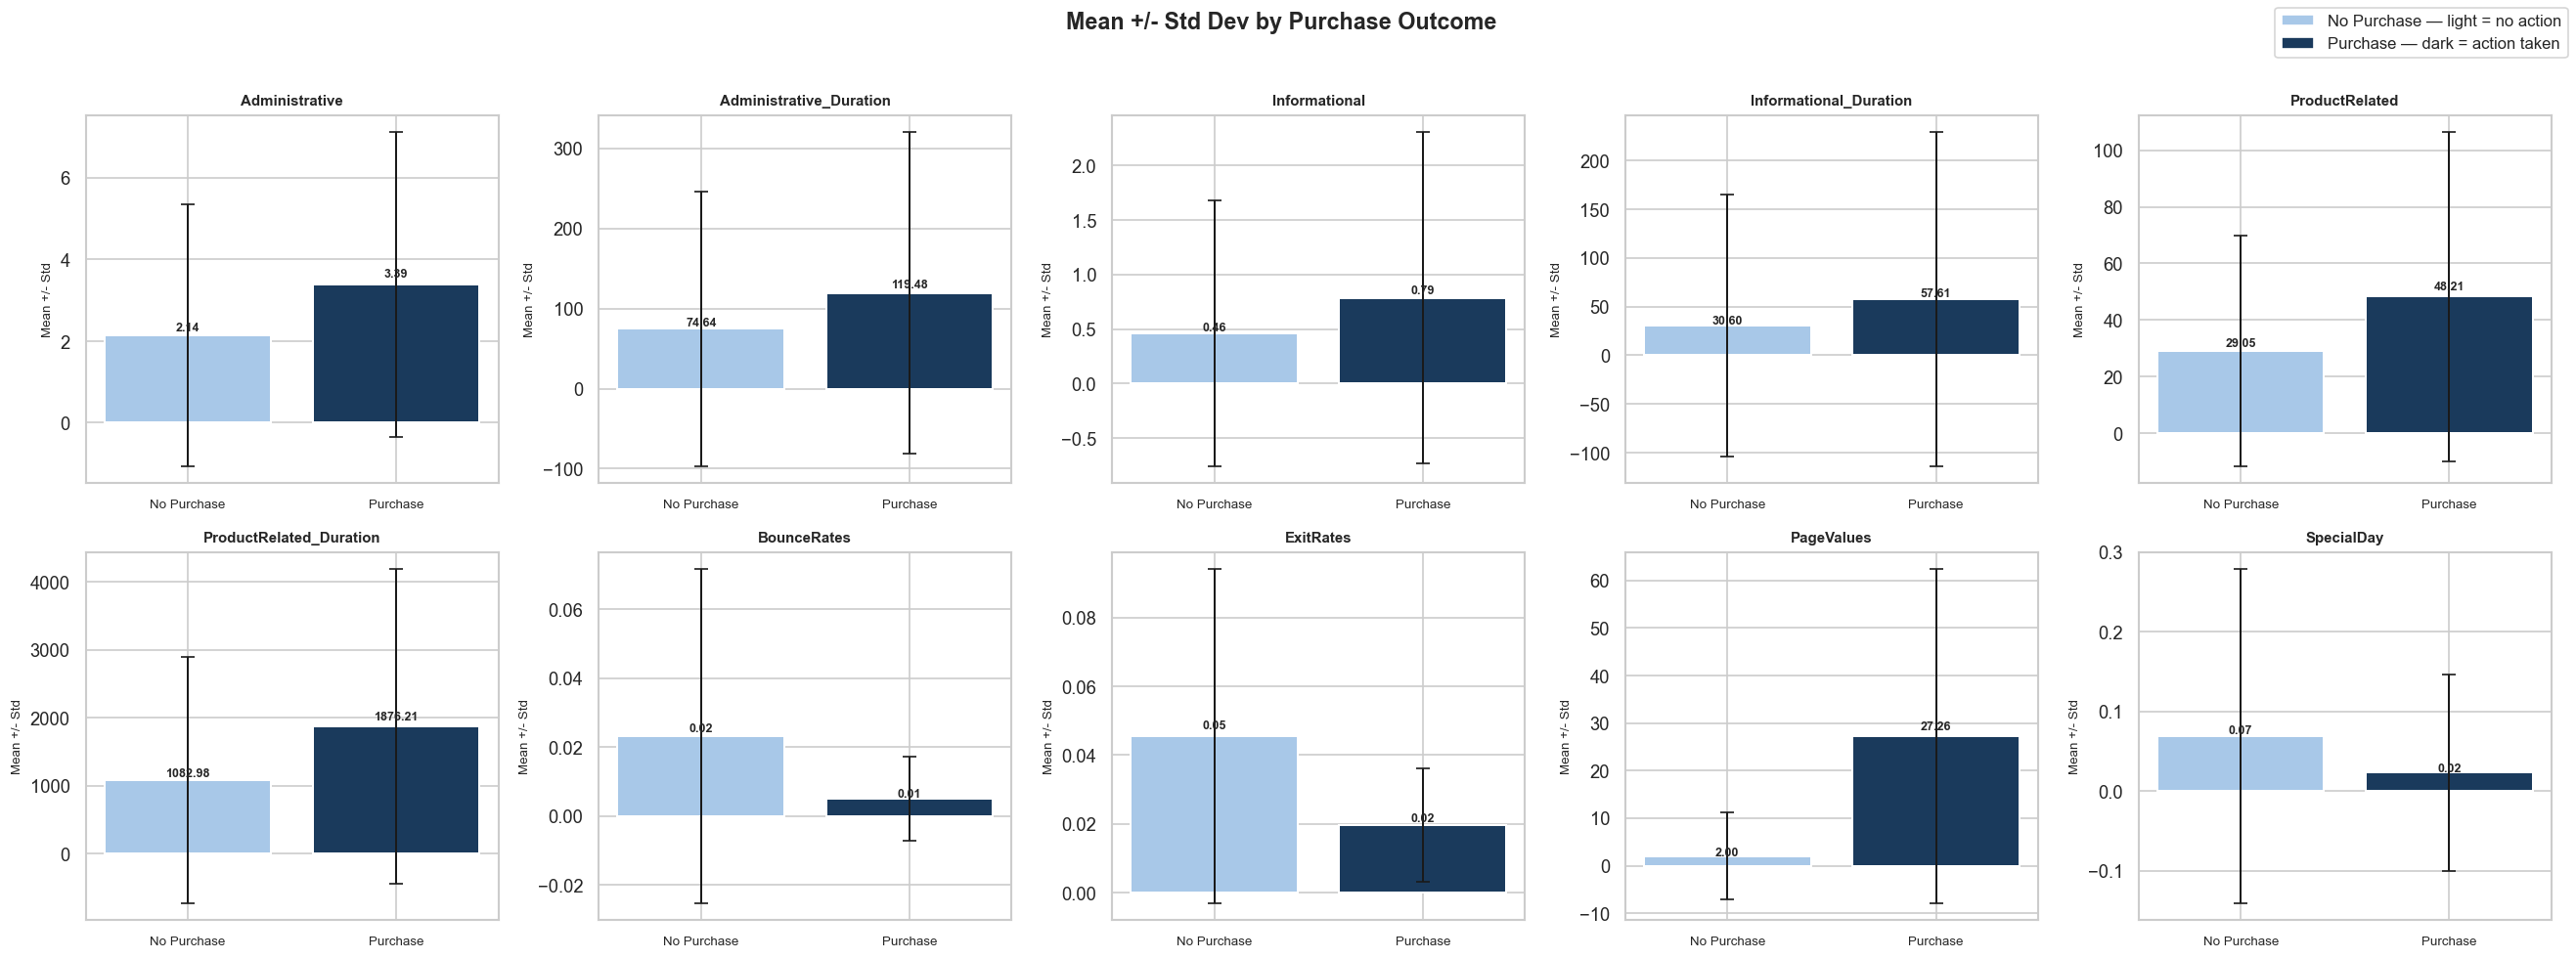

In [8]:
# COLOUR MEANING: Dark navy = Purchase | Light blue = No Purchase
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()
lbl  = ['No Purchase', 'Purchase']

for i, col in enumerate(numeric_cols):
    gm   = df.groupby('Revenue')[col].mean()
    gs   = df.groupby('Revenue')[col].std()
    bars = axes[i].bar(lbl, gm.values, yerr=gs.values, capsize=4,
                       color=[C_NO, C_YES], edgecolor='white', linewidth=1.2,
                       error_kw={'elinewidth': 1.2})
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].set_ylabel('Mean +/- Std', fontsize=8)
    axes[i].tick_params(axis='x', labelsize=8)
    for bar, val in zip(bars, gm.values):
        axes[i].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.05,
                     f'{val:.2f}', ha='center', fontsize=7.5, fontweight='bold')

legend_els = [Patch(facecolor=C_NO,  label='No Purchase — light = no action'),
              Patch(facecolor=C_YES, label='Purchase — dark = action taken')]
fig.legend(handles=legend_els, loc='upper right', fontsize=10)
plt.suptitle('Mean +/- Std Dev by Purchase Outcome',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

> **Insight:** `PageValues` shows the most dramatic mean difference — buyers average **27.27** vs non-buyers at **2.98**.

## 9. PageValues: The Strongest Predictor

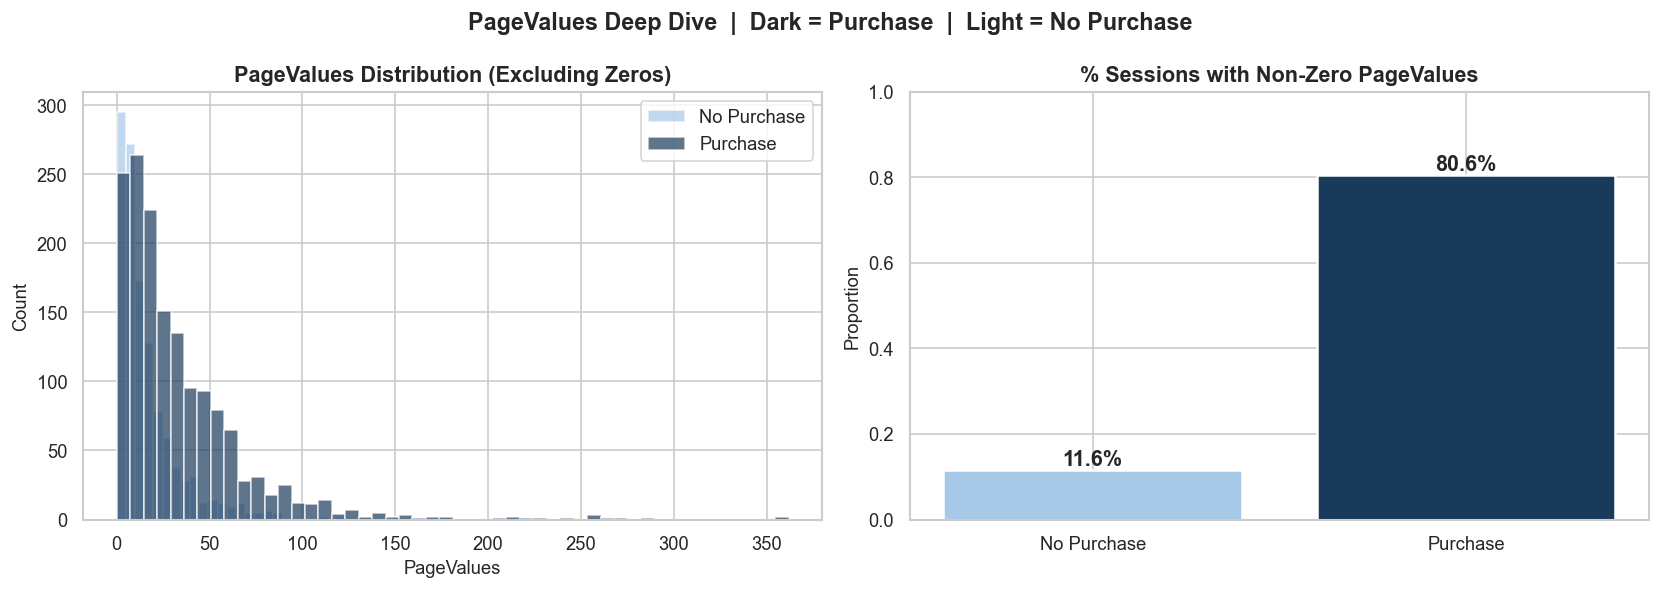

In [9]:
# COLOUR MEANING: Dark navy = Purchase | Light blue = No Purchase
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for rev, color, name in zip([0, 1], [C_NO, C_YES], ['No Purchase', 'Purchase']):
    subset = df[df['Revenue']==rev]['PageValues']
    axes[0].hist(subset[subset > 0], bins=50, alpha=0.7,
                 color=color, label=name, edgecolor='white')
axes[0].set_title('PageValues Distribution (Excluding Zeros)', fontweight='bold')
axes[0].set_xlabel('PageValues')
axes[0].set_ylabel('Count')
axes[0].legend()

pv_nonzero = df.groupby('Revenue').apply(
    lambda x: (x['PageValues'] > 0).mean()).reset_index()
pv_nonzero.columns = ['Revenue', 'Proportion']
bars = axes[1].bar(['No Purchase', 'Purchase'],
                   pv_nonzero['Proportion'],
                   color=[C_NO, C_YES], edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, pv_nonzero['Proportion']):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.01,
                 f'{v:.1%}', ha='center', fontweight='bold', fontsize=13)
axes[1].set_title('% Sessions with Non-Zero PageValues', fontweight='bold')
axes[1].set_ylabel('Proportion')
axes[1].set_ylim(0, 1)

plt.suptitle('PageValues Deep Dive  |  Dark = Purchase  |  Light = No Purchase',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

\> **Insight:** **80.6% of buyers** had a non-zero PageValues score compared to only **11.6% of non-buyers**: making it the single strongest binary signal in the dataset.

## 10. Categorical Feature Analysis

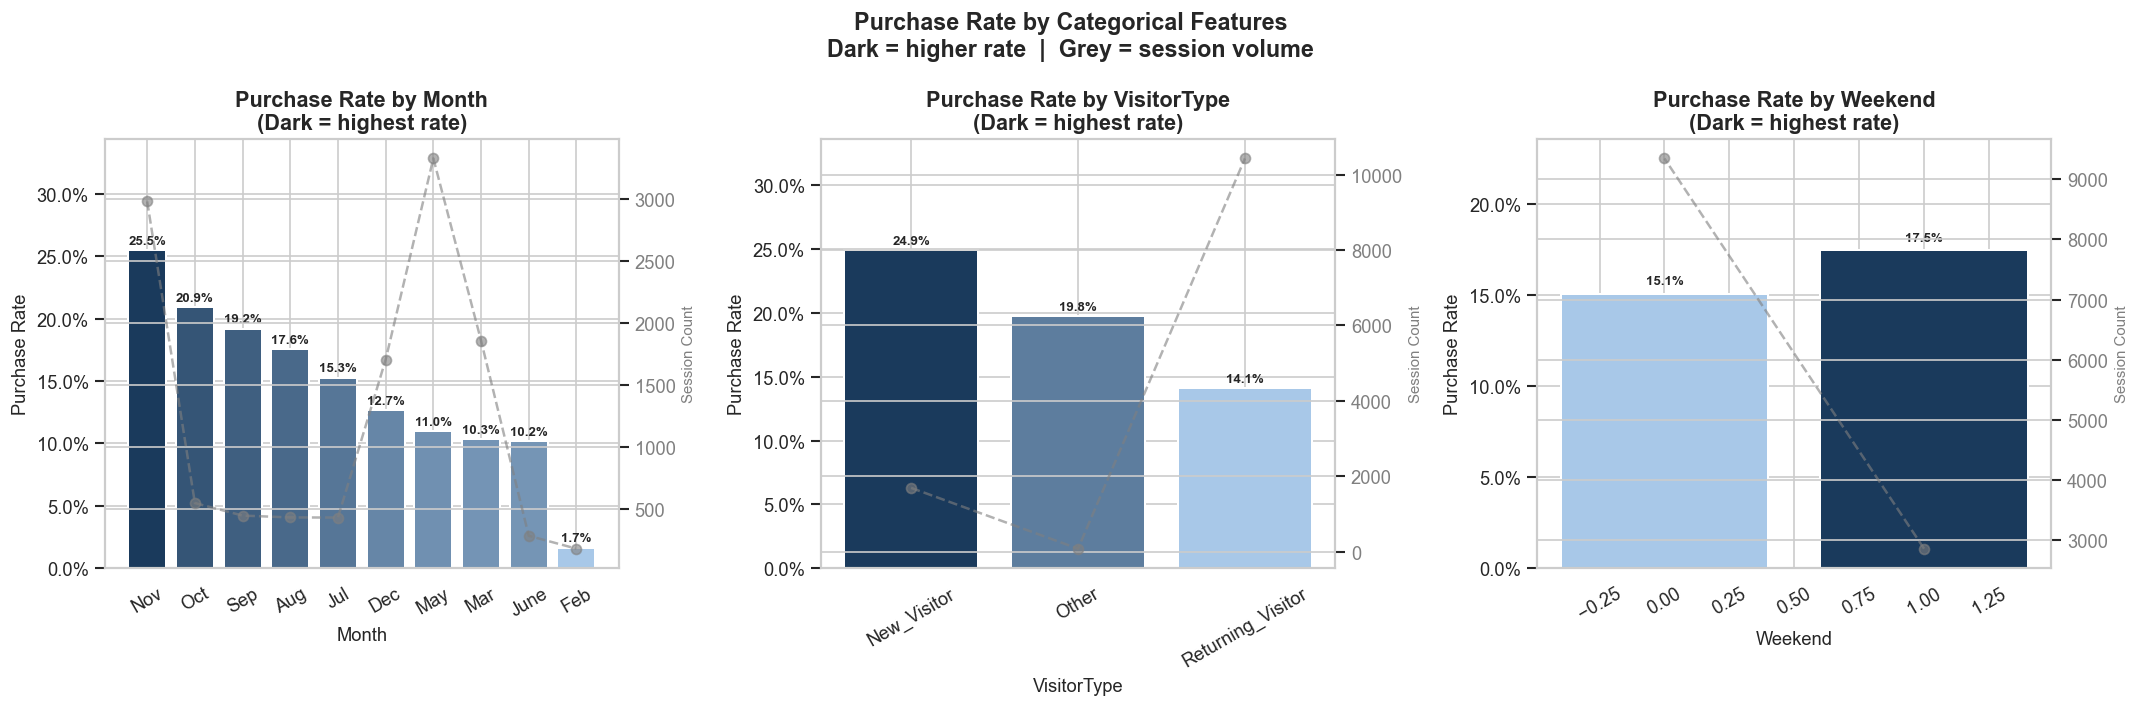

In [10]:
# COLOUR MEANING: Dark navy = highest purchase rate | Light blue = lowest
# Grey dashed line = session volume — shows if rate is based on enough sessions
cat_features = ['Month', 'VisitorType', 'Weekend']
fig, axes    = plt.subplots(1, 3, figsize=(18, 6))

for i, col in enumerate(cat_features):
    purchase_rate = df.groupby(col)['Revenue'].mean().sort_values(ascending=False)
    session_count = df[col].value_counts().reindex(purchase_rate.index)

    norm = plt.Normalize(purchase_rate.min(), purchase_rate.max())
    mapped_colors = []
    for v in norm(purchase_rate.values):
        r = int(0xa8 + v*(0x1a - 0xa8))
        g = int(0xc8 + v*(0x3a - 0xc8))
        b = int(0xe8 + v*(0x5c - 0xe8))
        mapped_colors.append(f'#{r:02x}{g:02x}{b:02x}')

    bars = axes[i].bar(purchase_rate.index, purchase_rate.values,
                       color=mapped_colors, edgecolor='white', linewidth=1.2)
    axes[i].set_title(f'Purchase Rate by {col}\n(Dark = highest rate)', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Purchase Rate')
    axes[i].set_ylim(0, purchase_rate.max() * 1.35)
    axes[i].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    for bar in bars:
        h = bar.get_height()
        axes[i].text(bar.get_x()+bar.get_width()/2, h+0.005,
                     f'{h:.1%}', ha='center', fontsize=8, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=30)

    ax2 = axes[i].twinx()
    ax2.plot(purchase_rate.index, session_count.values,
             color='grey', marker='o', linewidth=1.5,
             linestyle='--', alpha=0.6, label='Session Count')
    ax2.set_ylabel('Session Count', color='grey', fontsize=9)
    ax2.tick_params(axis='y', labelcolor='grey')

plt.suptitle('Purchase Rate by Categorical Features\nDark = higher rate  |  Grey = session volume',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

> **Insight:**
> - **Month:** November has the highest purchase rate at **25.5%** : driven by Black Friday / seasonal campaigns
> - **VisitorType:** Returning Visitors convert at a higher rate than New Visitors
> - **Weekend:** Slight uplift in purchase rate on weekends

## 11. Bounce Rate vs Exit Rate : Density by Purchase

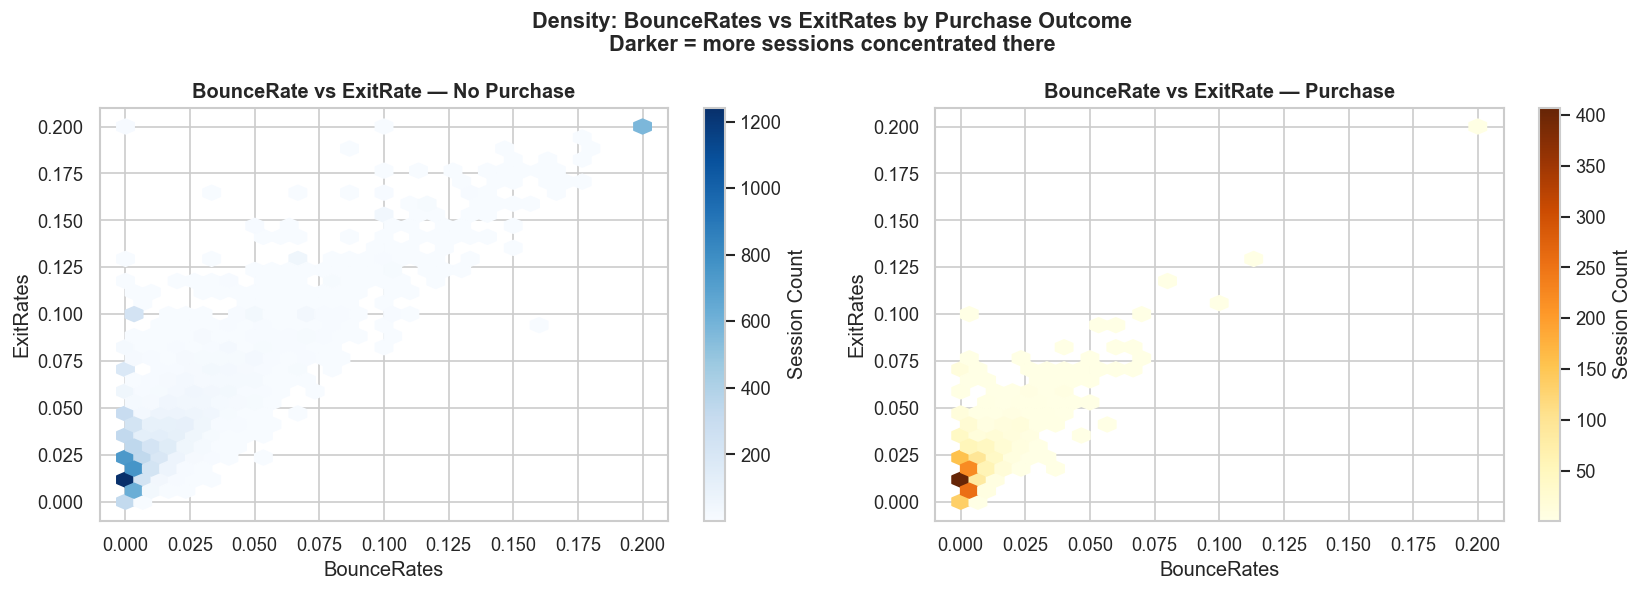

→ Non-buyers spread across higher BounceRates and ExitRates.
→ Buyers cluster tightly near zero :they stay and engage before buying.


In [63]:
# COLOUR MEANING: Left = No Purchase density (light blues)
#                 Right = Purchase density (warm tones — darker = more sessions)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, rev, cmap, name in zip(
        axes, [0, 1], ['Blues', 'YlOrBr'], ['No Purchase', 'Purchase']):
    subset = df[df['Revenue']==rev]
    hb = ax.hexbin(subset['BounceRates'], subset['ExitRates'],
                   gridsize=30, cmap=cmap, mincnt=1)
    plt.colorbar(hb, ax=ax, label='Session Count')
    ax.set_title(f'BounceRate vs ExitRate — {name}', fontweight='bold', fontsize=12)
    ax.set_xlabel('BounceRates')
    ax.set_ylabel('ExitRates')

plt.suptitle('Density: BounceRates vs ExitRates by Purchase Outcome\nDarker = more sessions concentrated there',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('→ Non-buyers spread across higher BounceRates and ExitRates.')
print('→ Buyers cluster tightly near zero :they stay and engage before buying.')

> **Insight:** Non-buyers are spread across a wide range of BounceRates and ExitRates. Buyers cluster tightly near zero: they stay and engage before buying.

## 12. Correlation Analysis

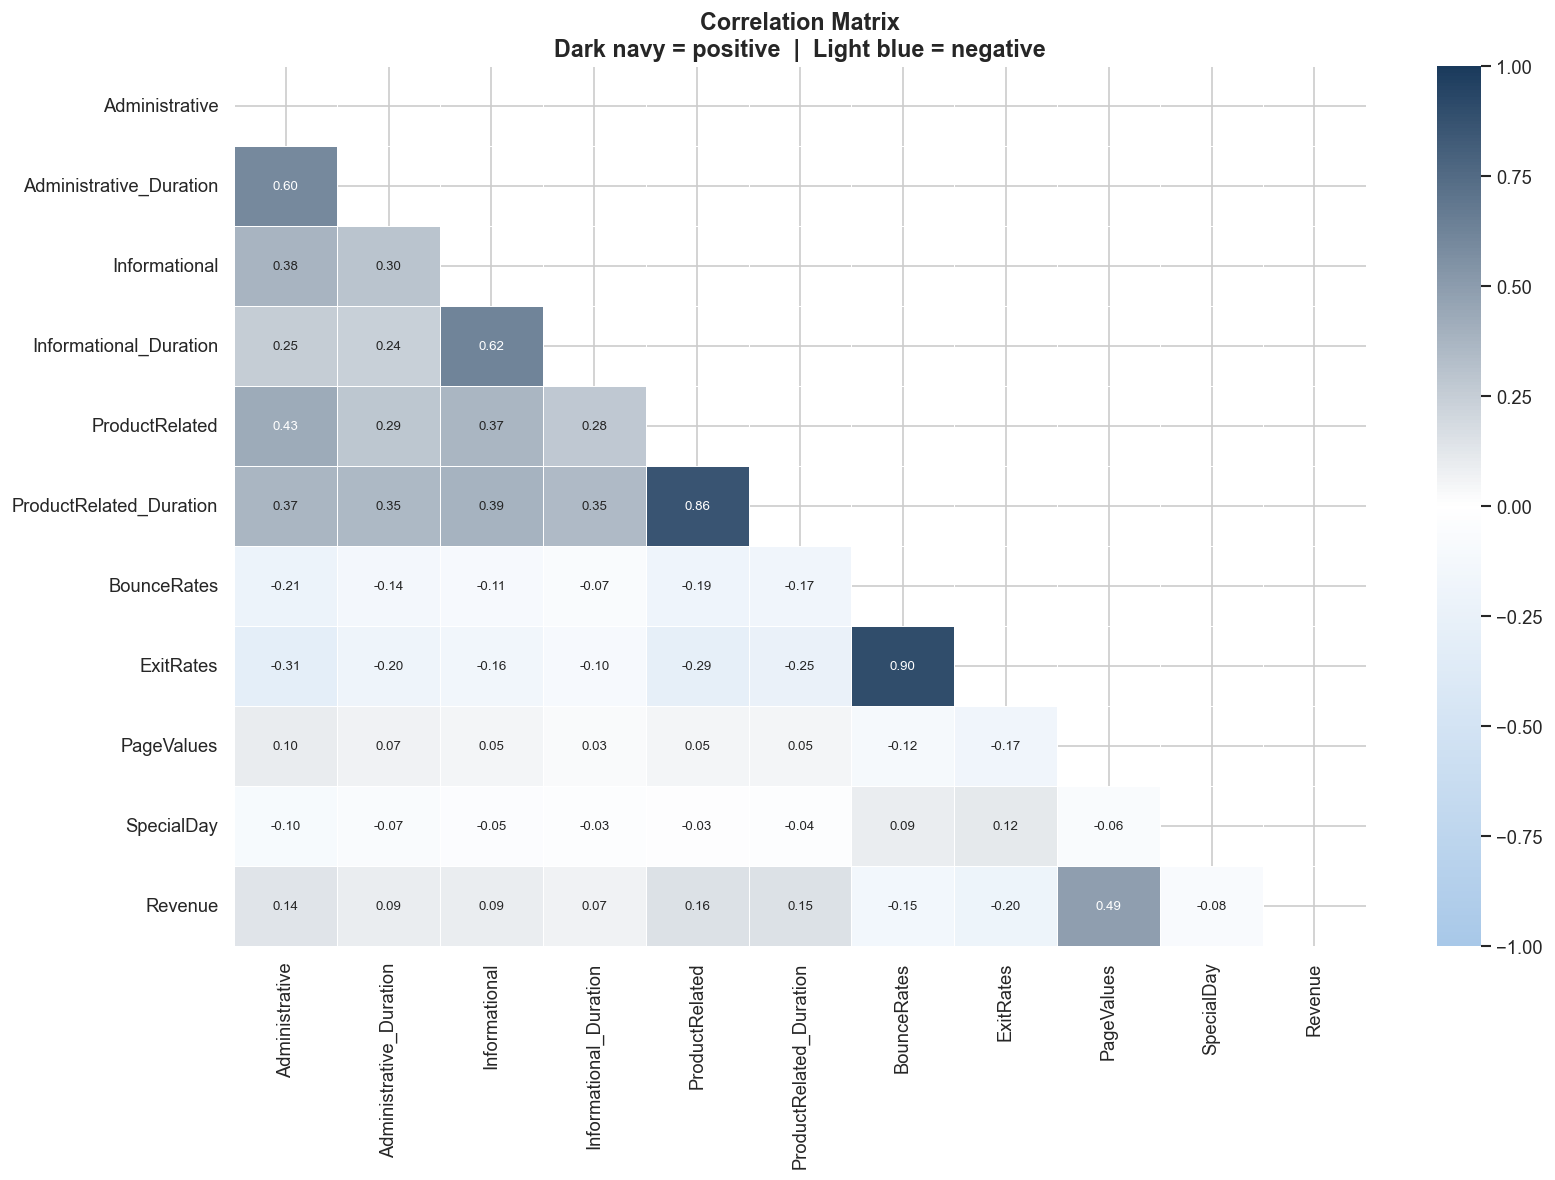

In [12]:
# COLOUR MEANING: Dark navy = strong positive correlation
#                 Light blue = strong negative correlation
from sklearn.preprocessing import LabelEncoder
le   = LabelEncoder()
data = df.copy()
data['Month']       = le.fit_transform(data['Month'])
data['VisitorType'] = le.fit_transform(data['VisitorType'])

corr = data[numeric_cols + ['Revenue']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

cmap_custom = LinearSegmentedColormap.from_list(
    'custom_div', [C_NO, 'white', C_YES], N=256)

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap=cmap_custom, center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white',
            ax=ax, annot_kws={'size': 8})
ax.set_title('Correlation Matrix\nDark navy = positive  |  Light blue = negative',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

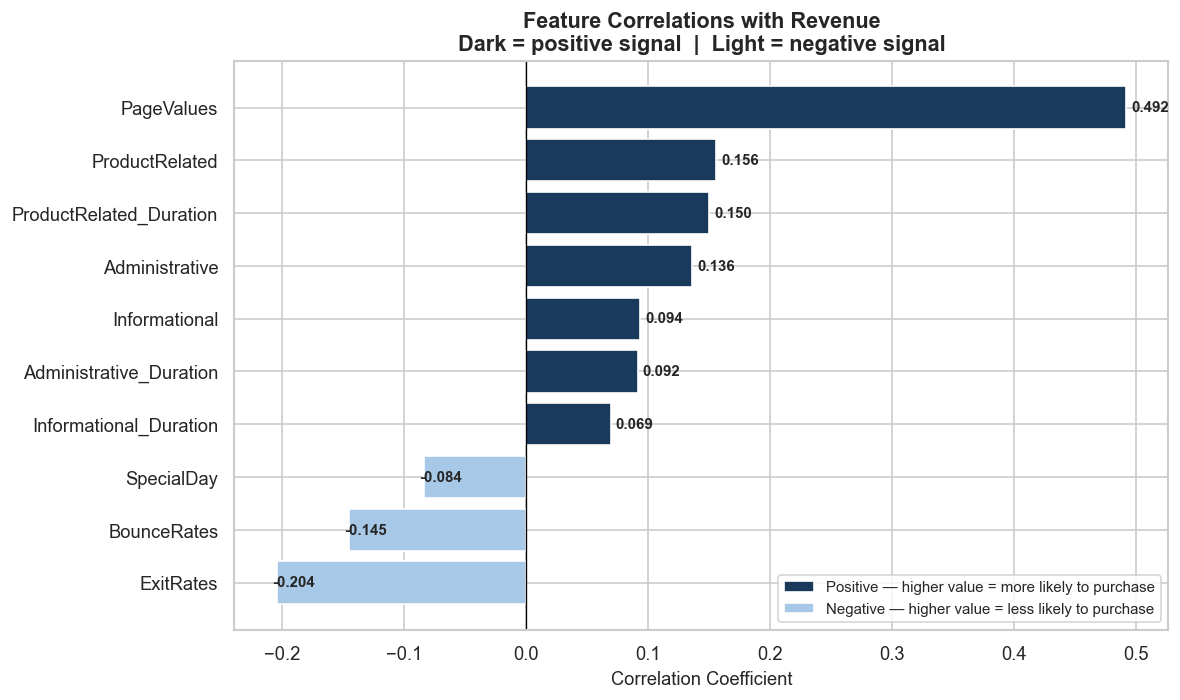

Top 5 features by correlation with Revenue:
PageValues                 0.492
ExitRates                 -0.204
ProductRelated             0.156
ProductRelated_Duration    0.150
BounceRates               -0.145


In [13]:
# Revenue correlation bar chart
# COLOUR MEANING: Dark navy = positive correlation (helps predict purchase)
#                 Light blue = negative correlation (inverse signal)
rev_corr   = corr['Revenue'].drop('Revenue').sort_values()
bar_colors = [C_YES if v > 0 else C_NO for v in rev_corr.values]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(rev_corr.index, rev_corr.values, color=bar_colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.004 if w >= 0 else w - 0.004,
            bar.get_y()+bar.get_height()/2,
            f'{w:.3f}', va='center', fontsize=9, fontweight='bold')
legend_els = [Patch(facecolor=C_YES, label='Positive — higher value = more likely to purchase'),
              Patch(facecolor=C_NO,  label='Negative — higher value = less likely to purchase')]
ax.legend(handles=legend_els, fontsize=9)
ax.set_title('Feature Correlations with Revenue\nDark = positive signal  |  Light = negative signal',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

print('Top 5 features by correlation with Revenue:')
print(corr['Revenue'].drop('Revenue').sort_values(key=abs, ascending=False).head().round(3).to_string())

> **Insight:** PageValues has by far the strongest correlation with Revenue at **0.492**. BounceRates and ExitRates are negatively correlated: higher rates mean less likely to purchase.

## 13. Traffic Type and Region Analysis

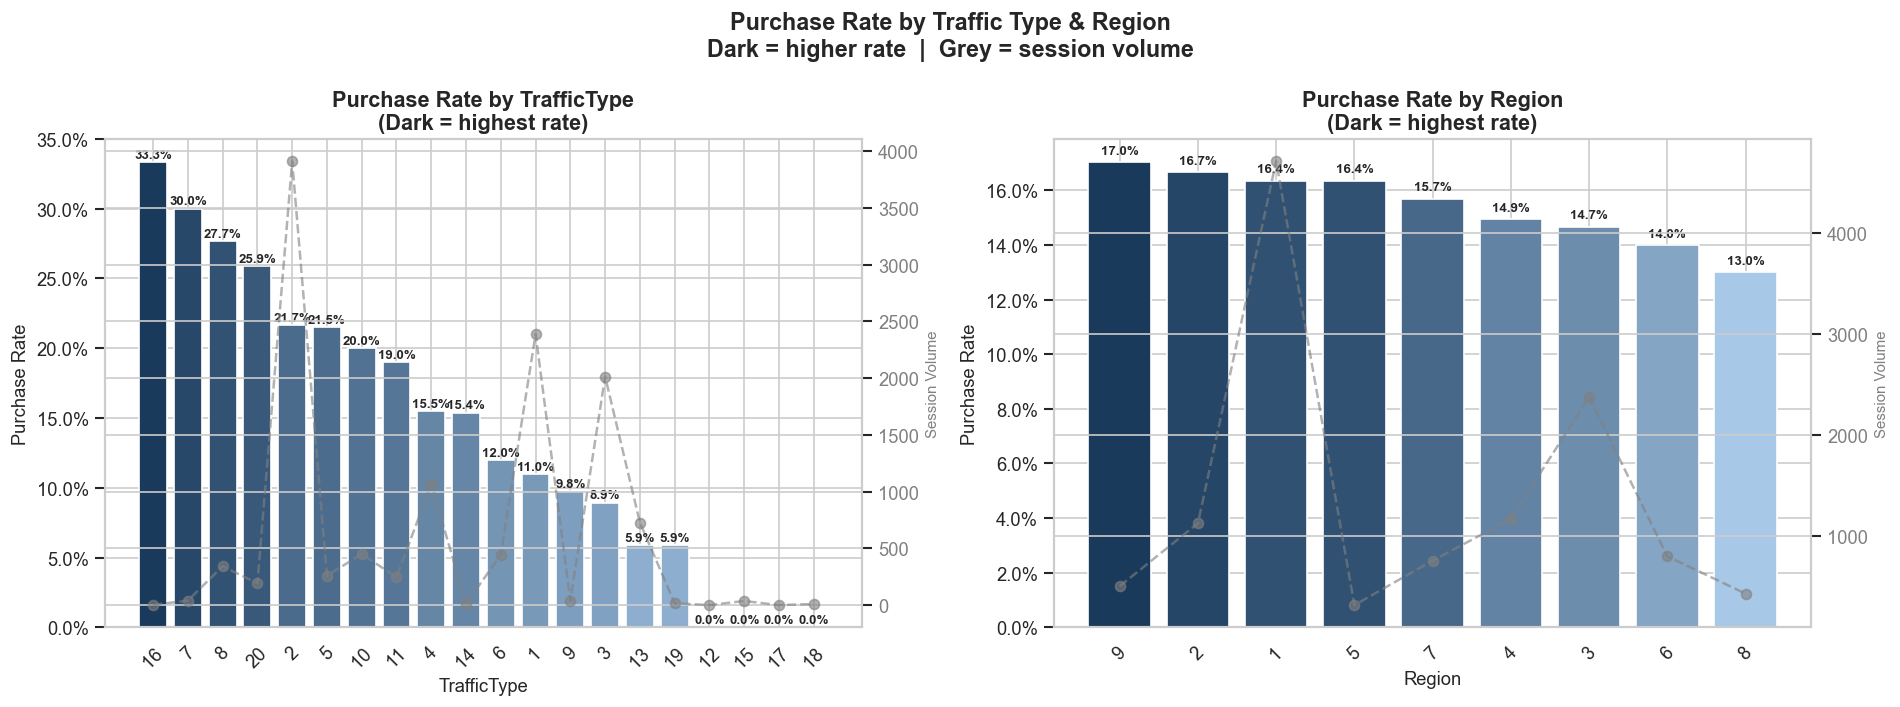

In [14]:
# COLOUR MEANING: Dark navy = highest purchase rate | Light blue = lowest
# Grey dashed = volume context
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, col in zip(axes, ['TrafficType', 'Region']):
    purchase_rate = df.groupby(col)['Revenue'].mean().sort_values(ascending=False)
    volume        = df[col].value_counts().reindex(purchase_rate.index)

    norm = plt.Normalize(purchase_rate.min(), purchase_rate.max())
    mapped_colors = []
    for v in norm(purchase_rate.values):
        r = int(0xa8 + v*(0x1a - 0xa8))
        g = int(0xc8 + v*(0x3a - 0xc8))
        b = int(0xe8 + v*(0x5c - 0xe8))
        mapped_colors.append(f'#{r:02x}{g:02x}{b:02x}')

    bars = ax.bar(purchase_rate.index.astype(str), purchase_rate.values,
                  color=mapped_colors, edgecolor='white')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.003,
                f'{h:.1%}', ha='center', fontsize=8, fontweight='bold')
    ax.set_title(f'Purchase Rate by {col}\n(Dark = highest rate)', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Purchase Rate')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.tick_params(axis='x', rotation=45)

    ax2 = ax.twinx()
    ax2.plot(purchase_rate.index.astype(str), volume.values,
             color='grey', marker='o', linewidth=1.5, linestyle='--', alpha=0.6)
    ax2.set_ylabel('Session Volume', color='grey', fontsize=9)
    ax2.tick_params(axis='y', labelcolor='grey')

plt.suptitle('Purchase Rate by Traffic Type & Region\nDark = higher rate  |  Grey = session volume',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

> **Insight:** Traffic type and region vary significantly in conversion rate. Some traffic types convert at over 20% while others barely reach 5% — useful for targeting decisions.

## 14. Outlier Detection: IQR Method

Outlier Summary (IQR Method):


,Outliers,Pct,Lower Fence,Upper Fence
Administrative,404.0,3.3,-6.000,10.000
Administrative_Duration,1149.0,9.4,-142.050,236.750
Informational,2631.0,21.6,0.000,0.000
Informational_Duration,2405.0,19.7,0.000,0.000
ProductRelated,1007.0,8.3,-37.000,83.000
ProductRelated_Duration,951.0,7.8,-1733.232,3403.387
BounceRates,1428.0,11.7,-0.025,0.042
ExitRates,1325.0,10.9,-0.037,0.100
PageValues,2730.0,22.4,0.000,0.000
SpecialDay,1249.0,10.2,0.000,0.000


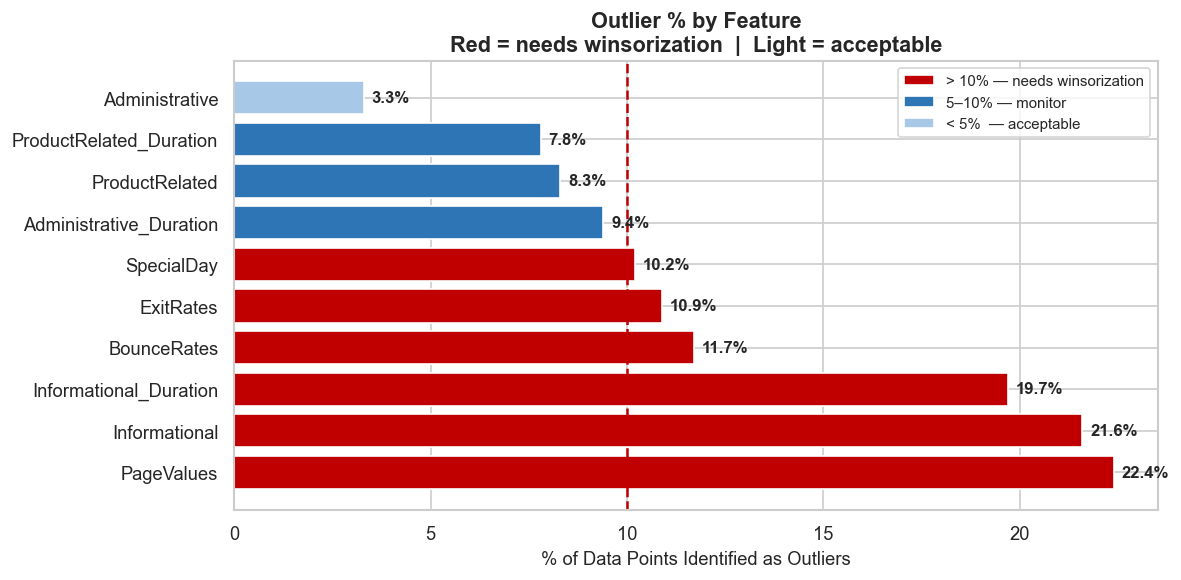

In [15]:
# COLOUR MEANING: Dark red = high outlier % (needs treatment)
#                 Mid blue = moderate (monitor)
#                 Light blue = acceptable (no action)
outlier_summary = {}
for col in numeric_cols:
    Q1, Q3  = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR     = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out   = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary[col] = {
        'Outliers': n_out,
        'Pct':      round(n_out/len(df)*100, 1),
        'Lower Fence': round(lower, 3),
        'Upper Fence': round(upper, 3)
    }

outlier_df = pd.DataFrame(outlier_summary).T
print('Outlier Summary (IQR Method):')
display(outlier_df)

pct_vals  = outlier_df['Pct'].astype(float).sort_values(ascending=False)
bar_cols  = [C_WARN if v > 10 else C_SINGLE if v > 5 else C_OK for v in pct_vals]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(pct_vals.index, pct_vals.values, color=bar_cols, edgecolor='white')
for bar in bars:
    ax.text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
            f'{bar.get_width():.1f}%', va='center', fontsize=10, fontweight='bold')
ax.axvline(10, color=C_WARN, lw=1.5, ls='--')
ax.set_title('Outlier % by Feature\nRed = needs winsorization  |  Light = acceptable',
             fontsize=13, fontweight='bold')
ax.set_xlabel('% of Data Points Identified as Outliers')
legend_els = [
    Patch(facecolor=C_WARN,   label='> 10% — needs winsorization'),
    Patch(facecolor=C_SINGLE, label='5–10% — monitor'),
    Patch(facecolor=C_OK,     label='< 5%  — acceptable')
]
ax.legend(handles=legend_els, fontsize=9)
plt.tight_layout()
plt.show()

> **Insight:** PageValues (**22.4%**) and Informational (**21.6%**) have the highest outlier rates — both exceed the 10% threshold (red). Consider winsorization before modelling.

## 15. EDA Summary and Key Findings

### Colour System Used
| Colour | Meaning |
|--------|---------|
| 🟦 Dark Navy `#1a3a5c` | Purchase / significant / action taken |
| 🩵 Light Blue `#a8c8e8` | No Purchase / acceptable / no action |
| 🔵 Mid Blue `#2e75b6` | Single-series neutral charts |
| 🔴 Dark Red `#c00000` | Warning / needs attention |

### Key Findings
1. **PageValues** is the single strongest predictor of purchase (r = 0.492)
2. Dataset is **heavily imbalanced** — 84.4% No Purchase vs 15.6% Purchase
3. **BounceRates & ExitRates** are significantly lower for buyers — they stay and engage
4. **November** has the highest purchase rate (25.5%) — seasonal effect
5. **Returning Visitors** convert at a higher rate than New Visitors
6. All 10 numeric features are **highly right-skewed** → apply **log1p** before modelling
8. **BounceRates & ExitRates** are highly correlated — watch for multicollinearity

---
# PART B: Statistical Analysis

This section covers formal statistical tests to validate the patterns observed in Part A.

In [64]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from scipy import stats
from scipy.stats import (mannwhitneyu, chi2_contingency, shapiro,
                         normaltest, pointbiserialr, kruskal)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    import statsmodels.api as sm
    HAS_STATSMODELS = True
except ImportError:
    HAS_STATSMODELS = False
    print(" statsmodels not found – install with: pip install statsmodels")
    print("  Section 5 (Odds Ratios) and Section 7 (VIF) will use fallback methods.\n")

In [17]:
# Colours updated to match Part A colour system
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11

# Match Part A colour system
BLUE   = '#a8c8e8'   # Light blue  — No Purchase / non-significant
ORANGE = '#1a3a5c'   # Dark navy   — Purchase / significant
GREEN  = '#2e75b6'   # Mid blue    — neutral accent

ALPHA  = 0.05        # Significance level

# Reuse df loaded in Part A
data       = df.copy()
buyers     = data[data['Revenue'] == 1]
non_buyers = data[data['Revenue'] == 0]

CONTINUOUS = [
    'Administrative', 'Administrative_Duration',
    'Informational',  'Informational_Duration',
    'ProductRelated', 'ProductRelated_Duration',
    'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay'
]
CATEGORICAL = ['Month', 'VisitorType', 'Weekend',
               'OperatingSystems', 'Browser', 'Region', 'TrafficType']

print(f'Total sessions : {len(data):,}')
print(f'Buyers         : {len(buyers):,}  ({len(buyers)/len(data)*100:.2f}%)')
print(f'Non-Buyers     : {len(non_buyers):,}  ({len(non_buyers)/len(data)*100:.2f}%)')

Total sessions : 12,205
Buyers         : 1,908  (15.63%)
Non-Buyers     : 10,297  (84.37%)


SECTION 1. **DESCRIPTIVE STATISTICS**

In [18]:
desc_rows = []
for col in CONTINUOUS:
    for group, label in [(buyers, 'Buyers'), (non_buyers, 'Non-Buyers')]:
        s = group[col]
        desc_rows.append({
            'Feature':  col,
            'Group':    label,
            'N':        len(s),
            'Mean':     round(s.mean(), 4),
            'Median':   round(s.median(), 4),
            'Std':      round(s.std(), 4),
            'Min':      round(s.min(), 4),
            'Max':      round(s.max(), 4),
            'Q1':       round(s.quantile(0.25), 4),
            'Q3':       round(s.quantile(0.75), 4),
            'Skewness': round(s.skew(), 4),
            'Kurtosis': round(s.kurtosis(), 4),
        })

desc_data = pd.DataFrame(desc_rows)
print(desc_data.to_string(index=False))


                Feature      Group     N      Mean    Median       Std  Min        Max       Q1        Q3  Skewness  Kurtosis
         Administrative     Buyers  1908    3.3936    2.0000    3.7305  0.0    26.0000   0.0000    5.0000    1.4550    2.4109
         Administrative Non-Buyers 10297    2.1434    1.0000    3.2133  0.0    27.0000   0.0000    3.0000    2.0787    5.4023
Administrative_Duration     Buyers  1908  119.4832   52.3667  201.1147  0.0  2086.7500   0.0000  151.0833    3.9852   23.1537
Administrative_Duration Non-Buyers 10297   74.6353    0.0000  171.8587  0.0  3398.7500   0.0000   84.5500    6.0731   59.4663
          Informational     Buyers  1908    0.7862    0.0000    1.5212  0.0    12.0000   0.0000    1.0000    2.6986    9.2896
          Informational Non-Buyers 10297    0.4573    0.0000    1.2179  0.0    24.0000   0.0000    0.0000    4.4213   33.5452
 Informational_Duration     Buyers  1908   57.6114    0.0000  171.6191  0.0  1767.6667   0.0000   19.0000    4.9826   

1st Plot: Mean Comparison Chart

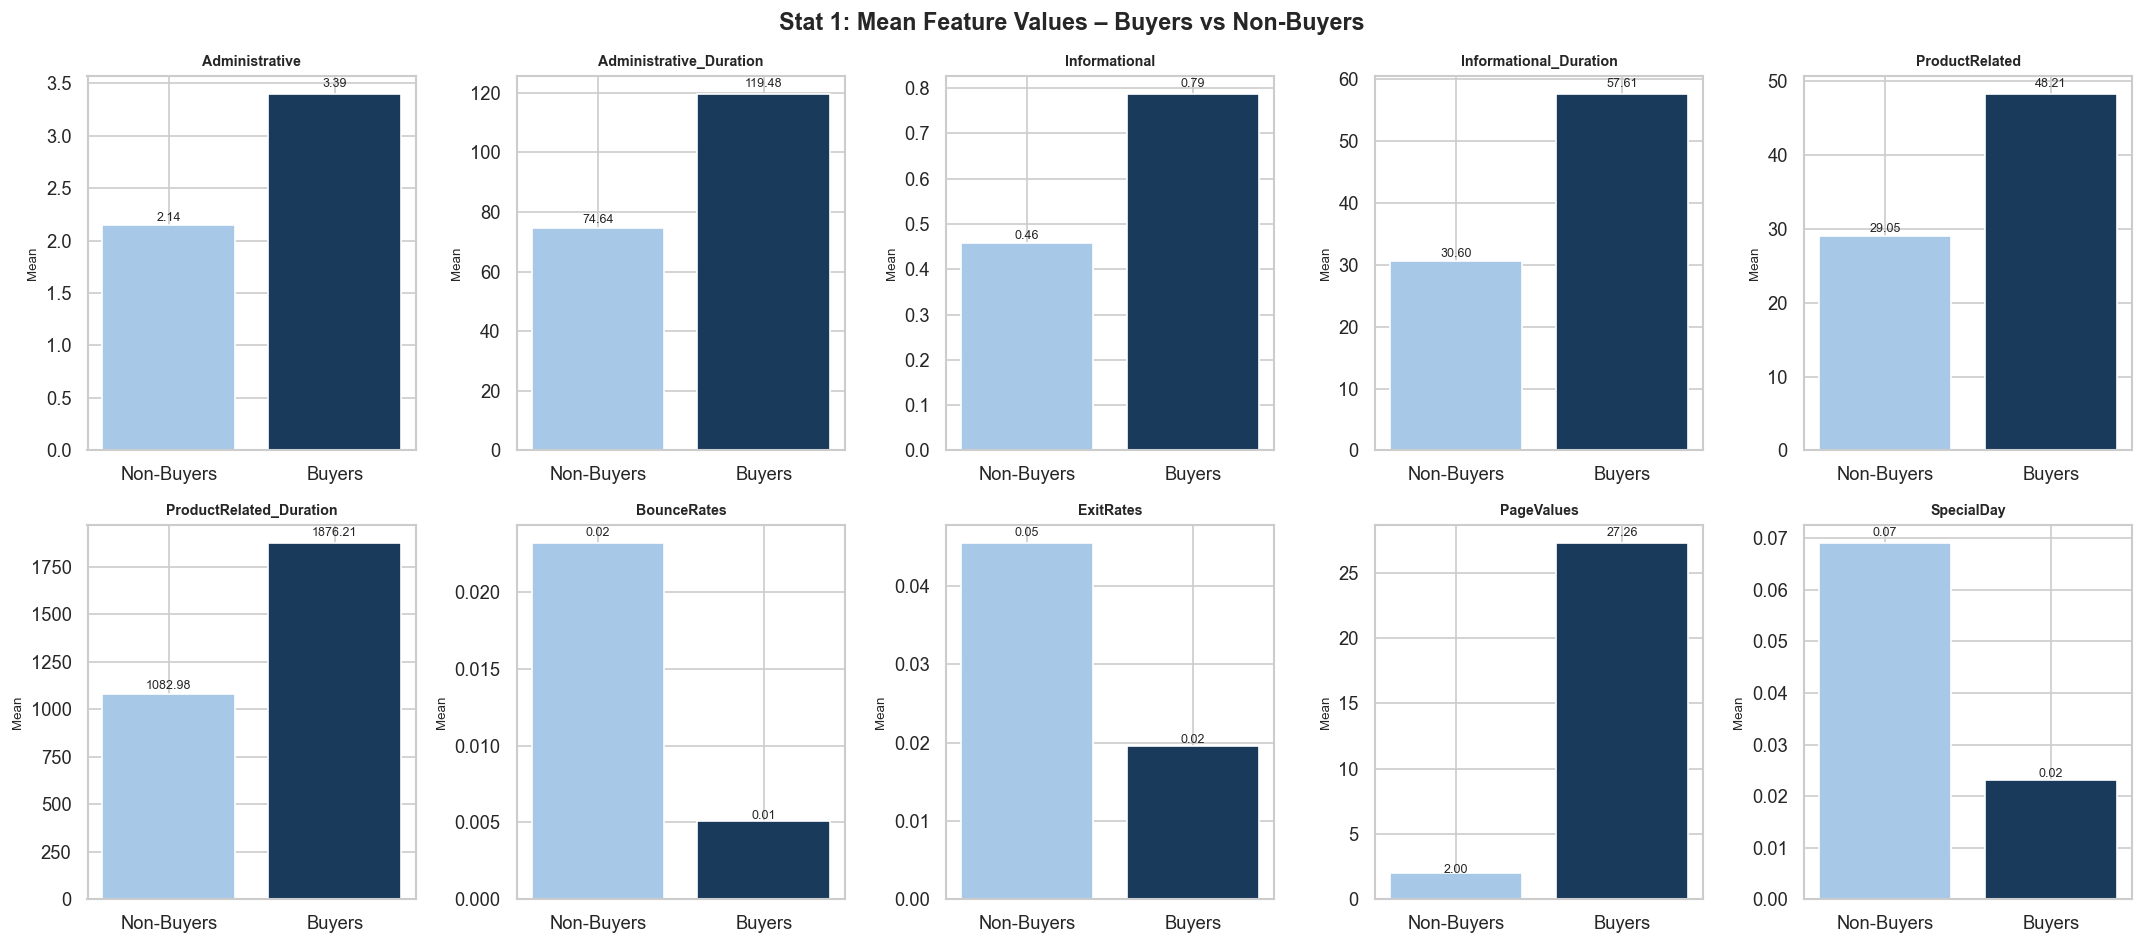


✅ Stat 1 – Mean comparison chart saved.


In [19]:
# ── Stat 1 Plot: Mean comparison bar chart ────────────────────
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.suptitle('Stat 1: Mean Feature Values – Buyers vs Non-Buyers',
             fontsize=14, fontweight='bold')

for ax, col in zip(axes.flat, CONTINUOUS):
    means = [non_buyers[col].mean(), buyers[col].mean()]
    ax.bar(['Non-Buyers', 'Buyers'], means,
           color=[BLUE, ORANGE], edgecolor='white')
    ax.set_title(col, fontsize=8.5, fontweight='bold')
    ax.set_ylabel('Mean', fontsize=8)
    for i, v in enumerate(means):
        ax.text(i, v * 1.02, f'{v:.2f}', ha='center', fontsize=7.5)

plt.tight_layout()
plt.savefig('stat1_mean_comparison.png', bbox_inches='tight')
plt.show()
print("\n✅ Stat 1 – Mean comparison chart saved.")

2. **NORMALITY TESTING**
(Shapiro-Wilk for n≤5000 | D'Agostino-Pearson for n>5000)

In [20]:
norm_rows = []
for col in CONTINUOUS:
    for group, label in [(buyers, 'Buyers'), (non_buyers, 'Non-Buyers')]:
        s = group[col].dropna()
        n = len(s)
        if n <= 5000:
            stat, p = shapiro(s.sample(min(n, 5000), random_state=42))
            test_used = "Shapiro-Wilk"
        else:
            stat, p = normaltest(s)
            test_used = "D'Agostino-Pearson"

        norm_rows.append({
            'Feature':   col,
            'Group':     label,
            'N':         n,
            'Test':      test_used,
            'Statistic': round(stat, 4),
            'p-value':   round(p, 6),
            'Normal?':   'Yes' if p > ALPHA else 'No ✗'
        })

norm_data = pd.DataFrame(norm_rows)
print(norm_data.to_string(index=False))

normal_count = (norm_data['Normal?'] == 'Yes').sum()
print(f"\n  → {normal_count}/{len(norm_data)} tests suggest normality.")
print("  → Most features are NON-NORMAL → non-parametric tests will be used.")


                Feature      Group     N               Test  Statistic  p-value Normal?
         Administrative     Buyers  1908       Shapiro-Wilk     0.8382      0.0    No ✗
         Administrative Non-Buyers 10297 D'Agostino-Pearson  4378.4623      0.0    No ✗
Administrative_Duration     Buyers  1908       Shapiro-Wilk     0.5959      0.0    No ✗
Administrative_Duration Non-Buyers 10297 D'Agostino-Pearson 11975.4432      0.0    No ✗
          Informational     Buyers  1908       Shapiro-Wilk     0.5883      0.0    No ✗
          Informational Non-Buyers 10297 D'Agostino-Pearson  9597.0889      0.0    No ✗
 Informational_Duration     Buyers  1908       Shapiro-Wilk     0.3806      0.0    No ✗
 Informational_Duration Non-Buyers 10297 D'Agostino-Pearson 14472.3253      0.0    No ✗
         ProductRelated     Buyers  1908       Shapiro-Wilk     0.6663      0.0    No ✗
         ProductRelated Non-Buyers 10297 D'Agostino-Pearson 10052.0554      0.0    No ✗
ProductRelated_Duration     Buye




3a. HYPOTHESIS TESTING – MANN-WHITNEY U
(Non-parametric alternative to t-test)

In [21]:

print("\n\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("  SECTION 3a – MANN-WHITNEY U TEST")
print("  H0: No difference in distributions between Buyers & Non-Buyers")
print(f"  Reject H0 if p < {ALPHA}")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")

mwu_rows = []
for col in CONTINUOUS:
    b  = buyers[col].dropna()
    nb = non_buyers[col].dropna()
    u_stat, p = mannwhitneyu(b, nb, alternative='two-sided')

    # Rank-biserial effect size  r = 1 - (2U / n1*n2)
    r_rb = 1 - (2 * u_stat) / (len(b) * len(nb))

    mwu_rows.append({
        'Feature':           col,
        'Buyer Median':      round(b.median(), 4),
        'Non-Buyer Median':  round(nb.median(), 4),
        'U-Statistic':       round(u_stat, 2),
        'p-value':           round(p, 6),
        'Significant?':      'Yes ✓' if p < ALPHA else 'No',
        'Effect r (rb)':     round(r_rb, 4),
        'Effect Size':       ('Large'  if abs(r_rb) >= 0.5 else
                              'Medium' if abs(r_rb) >= 0.3 else
                              'Small'  if abs(r_rb) >= 0.1 else 'Negligible')
    })

mwu_data = pd.DataFrame(mwu_rows)
print(mwu_data.to_string(index=False))

sig_features = mwu_data[mwu_data['Significant?'] == 'Yes ✓']['Feature'].tolist()
print(f"\n  → {len(sig_features)} features show significant difference: {sig_features}")



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SECTION 3a – MANN-WHITNEY U TEST
  H0: No difference in distributions between Buyers & Non-Buyers
  Reject H0 if p < 0.05
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                Feature  Buyer Median  Non-Buyer Median  U-Statistic  p-value Significant?  Effect r (rb) Effect Size
         Administrative        2.0000            1.0000   12257665.5      0.0        Yes ✓        -0.2478       Small
Administrative_Duration       52.3667            0.0000   12193811.0      0.0        Yes ✓        -0.2413       Small
          Informational        0.0000            0.0000   11078871.5      0.0        Yes ✓        -0.1278       Small
 Informational_Duration        0.0000            0.0000   11018964.5      0.0        Yes ✓        -0.1217       Small
         ProductRelated       29.0000           16.0000   12856227.0      0.0        Yes ✓        -0.3087      Medium
ProductRelated_Duration     1109.9062         

 ── Stat 3a Plot: p-value significance bar ────────────────────

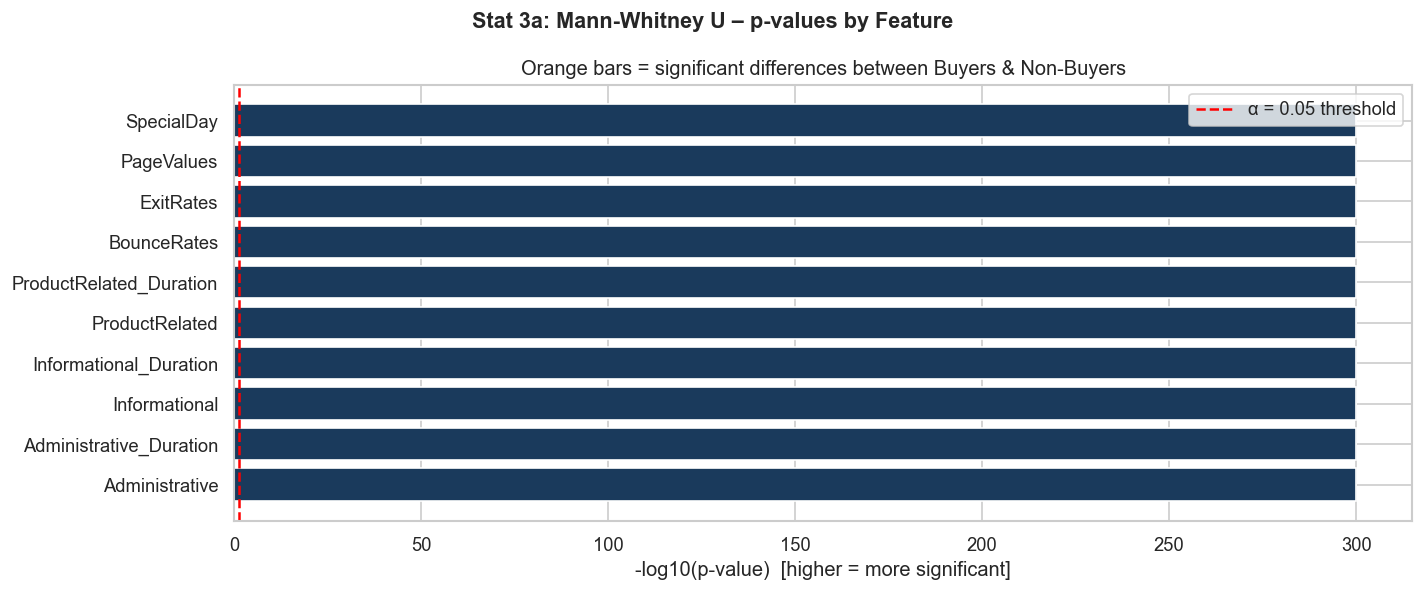


✅ Stat 3a – Mann-Whitney plot saved.


In [22]:

fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle('Stat 3a: Mann-Whitney U – p-values by Feature',
             fontsize=13, fontweight='bold')

colors = [ORANGE if p < ALPHA else BLUE for p in mwu_data['p-value']]
ax.barh(mwu_data['Feature'], -np.log10(mwu_data['p-value'].clip(lower=1e-300)),
        color=colors, edgecolor='white')
ax.axvline(-np.log10(ALPHA), color='red', linestyle='--',
           linewidth=1.5, label=f'α = {ALPHA} threshold')
ax.set_xlabel('-log10(p-value)  [higher = more significant]')
ax.set_title('Orange bars = significant differences between Buyers & Non-Buyers')
ax.legend()
plt.tight_layout()
plt.savefig('stat3a_mannwhitney.png', bbox_inches='tight')
plt.show()
print("\n✅ Stat 3a – Mann-Whitney plot saved.")


3b. HYPOTHESIS TESTING – CHI-SQUARE
  Categorical features vs Revenue

In [23]:
print("\n\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("  SECTION 3b – CHI-SQUARE TEST OF INDEPENDENCE")
print("  H0: Categorical feature is independent of Revenue")
print(f"  Reject H0 if p < {ALPHA}")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SECTION 3b – CHI-SQUARE TEST OF INDEPENDENCE
  H0: Categorical feature is independent of Revenue
  Reject H0 if p < 0.05
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


In [24]:

chi_rows = []
for col in CATEGORICAL:
    ct = pd.crosstab(data[col], data['Revenue'])
    chi2, p, dof, expected = chi2_contingency(ct)

    n    = ct.values.sum()
    phi2 = chi2 / n
    r, k = ct.shape
    cramers_v = np.sqrt(phi2 / min(k - 1, r - 1))

    chi_rows.append({
        'Feature':     col,
        'Chi2':        round(chi2, 4),
        'p-value':     round(p, 6),
        'DoF':         dof,
        'Significant?':    'Yes ✓' if p < ALPHA else 'No',
        "Cramér's V":  round(cramers_v, 4),
        'Association': ('Strong'   if cramers_v >= 0.35 else
                        'Moderate' if cramers_v >= 0.2  else
                        'Weak'     if cramers_v >= 0.1  else 'Negligible')
    })

chi_data = pd.DataFrame(chi_rows)
print(chi_data.to_string(index=False))


         Feature     Chi2  p-value  DoF Significant?  Cramér's V Association
           Month 376.2798 0.000000    9        Yes ✓      0.1756        Weak
     VisitorType 130.6676 0.000000    2        Yes ✓      0.1035        Weak
         Weekend   9.2048 0.002414    1        Yes ✓      0.0275  Negligible
OperatingSystems  75.0699 0.000000    7        Yes ✓      0.0784  Negligible
         Browser  29.1190 0.003783   12        Yes ✓      0.0488  Negligible
          Region   9.6794 0.288256    8           No      0.0282  Negligible
     TrafficType 359.2248 0.000000   19        Yes ✓      0.1716        Weak


Stat 3b Plot: Cramér's V ba

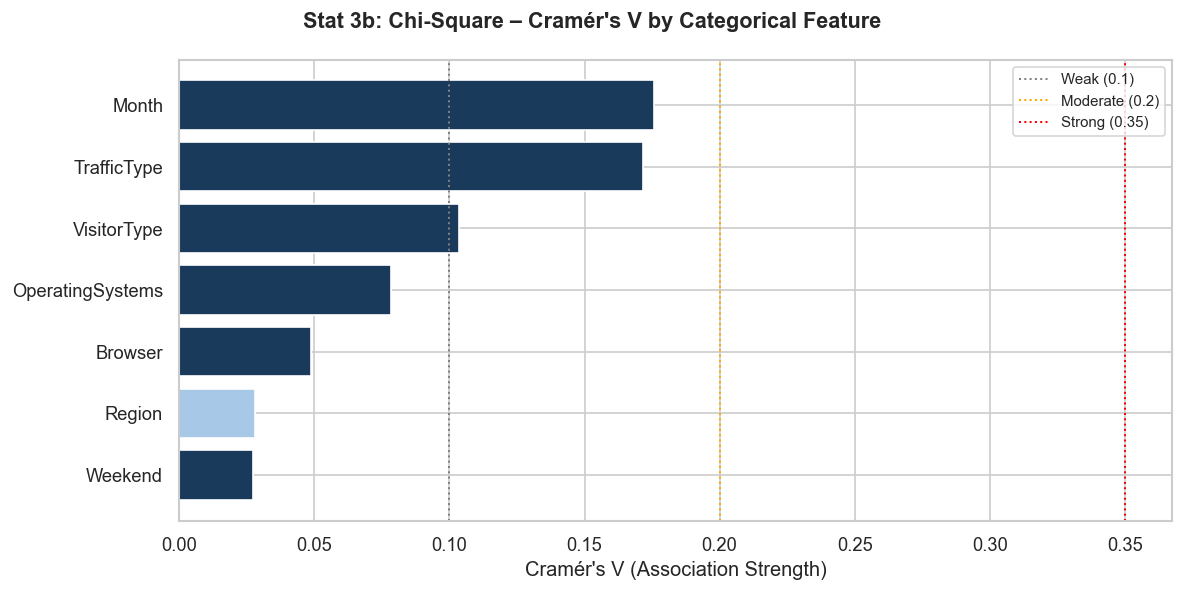


✅ Stat 3b – Chi-square plot saved.


In [25]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("Stat 3b: Chi-Square – Cramér's V by Categorical Feature",
             fontsize=13, fontweight='bold')

chi_sorted = chi_data.sort_values("Cramér's V", ascending=True)
colors = [ORANGE if s == 'Yes ✓' else BLUE for s in chi_sorted['Significant?']]
ax.barh(chi_sorted['Feature'], chi_sorted["Cramér's V"],
        color=colors, edgecolor='white')
ax.axvline(0.1, color='grey',   linestyle=':', linewidth=1.2, label='Weak (0.1)')
ax.axvline(0.2, color='orange', linestyle=':', linewidth=1.2, label='Moderate (0.2)')
ax.axvline(0.35,color='red',    linestyle=':', linewidth=1.2, label='Strong (0.35)')
ax.set_xlabel("Cramér's V (Association Strength)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('stat3b_chisquare.png', bbox_inches='tight')
plt.show()
print("\n✅ Stat 3b – Chi-square plot saved.")


3c. POINT-BISERIAL CORRELATION

In [26]:
print("\n\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("  SECTION 3c – POINT-BISERIAL CORRELATION vs Revenue")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")




━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SECTION 3c – POINT-BISERIAL CORRELATION vs Revenue
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


In [27]:

pb_rows = []
for col in CONTINUOUS:
    r, p = pointbiserialr(data['Revenue'], data[col])
    pb_rows.append({
        'Feature':      col,
        'r (pb)':       round(r, 4),
        'p-value':      round(p, 6),
        'Significant?': 'Yes ✓' if p < ALPHA else 'No',
        'Direction':    'Positive (+)' if r > 0 else 'Negative (−)'
    })

pb_data = pd.DataFrame(pb_rows).sort_values('r (pb)', ascending=False)
print(pb_data.to_string(index=False))


                Feature  r (pb)  p-value Significant?    Direction
             PageValues  0.4919      0.0        Yes ✓ Positive (+)
         ProductRelated  0.1560      0.0        Yes ✓ Positive (+)
ProductRelated_Duration  0.1501      0.0        Yes ✓ Positive (+)
         Administrative  0.1363      0.0        Yes ✓ Positive (+)
          Informational  0.0936      0.0        Yes ✓ Positive (+)
Administrative_Duration  0.0918      0.0        Yes ✓ Positive (+)
 Informational_Duration  0.0694      0.0        Yes ✓ Positive (+)
             SpecialDay -0.0836      0.0        Yes ✓ Negative (−)
            BounceRates -0.1451      0.0        Yes ✓ Negative (−)
              ExitRates -0.2043      0.0        Yes ✓ Negative (−)


Stat 3c Plot: Correlation bar

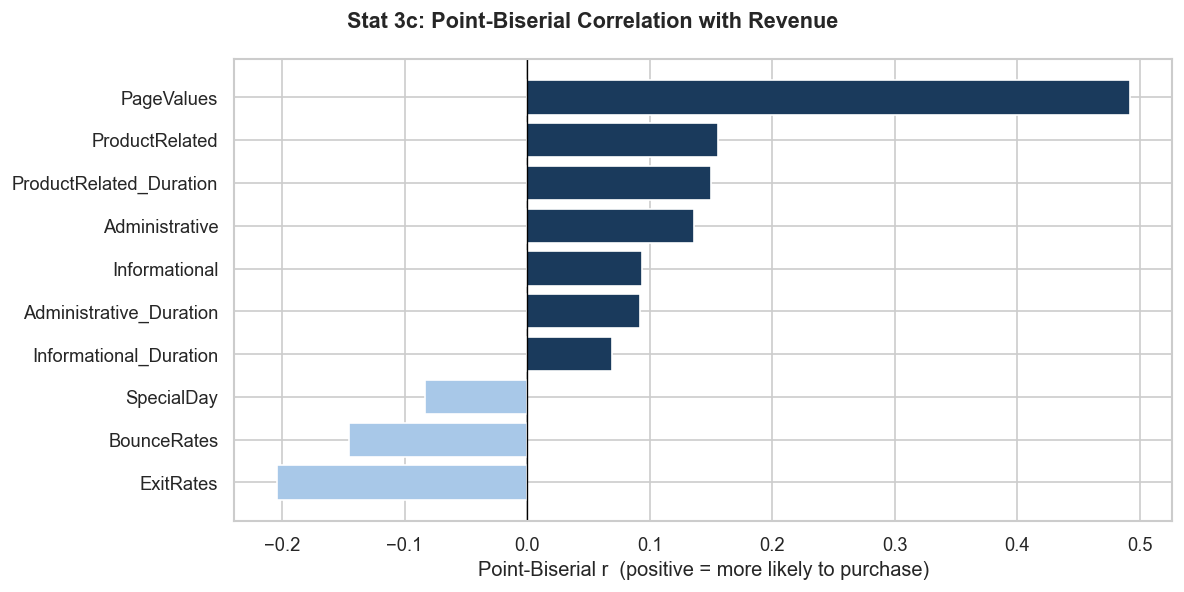


✅ Stat 3c – Point-biserial plot saved.


In [28]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Stat 3c: Point-Biserial Correlation with Revenue',
             fontsize=13, fontweight='bold')

pb_sorted = pb_data.sort_values('r (pb)')
colors = [ORANGE if r > 0 else BLUE for r in pb_sorted['r (pb)']]
ax.barh(pb_sorted['Feature'], pb_sorted['r (pb)'],
        color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Point-Biserial r  (positive = more likely to purchase)')
plt.tight_layout()
plt.savefig('stat3c_pointbiserial.png', bbox_inches='tight')
plt.show()
print("\n✅ Stat 3c – Point-biserial plot saved.")

4. EFFECT SIZE – COHEN'S D

In [29]:
print("\n\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("  SECTION 4 – EFFECT SIZE (Cohen's d)")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SECTION 4 – EFFECT SIZE (Cohen's d)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


In [30]:

def cohens_d(a, b):
    pooled_std = np.sqrt((a.std()**2 + b.std()**2) / 2)
    return (a.mean() - b.mean()) / pooled_std if pooled_std != 0 else 0


es_rows = []
for col in CONTINUOUS:
    d = cohens_d(buyers[col], non_buyers[col])
    es_rows.append({
        'Feature':       col,
        "Cohen's d":     round(d, 4),
        'Abs d':         round(abs(d), 4),
        'Effect Size':   ('Large'  if abs(d) >= 0.8 else
                          'Medium' if abs(d) >= 0.5 else
                          'Small'  if abs(d) >= 0.2 else 'Negligible'),
        'Direction':     'Buyers Higher' if d > 0 else 'Non-Buyers Higher'
    })

es_data = pd.DataFrame(es_rows).sort_values('Abs d', ascending=False)
print(es_data.to_string(index=False))

                Feature  Cohen's d  Abs d Effect Size         Direction
             PageValues     0.9828 0.9828       Large     Buyers Higher
              ExitRates    -0.7146 0.7146      Medium Non-Buyers Higher
            BounceRates    -0.5116 0.5116      Medium Non-Buyers Higher
ProductRelated_Duration     0.3820 0.3820       Small     Buyers Higher
         ProductRelated     0.3807 0.3807       Small     Buyers Higher
         Administrative     0.3591 0.3591       Small     Buyers Higher
             SpecialDay    -0.2668 0.2668       Small Non-Buyers Higher
Administrative_Duration     0.2398 0.2398       Small     Buyers Higher
          Informational     0.2387 0.2387       Small     Buyers Higher
 Informational_Duration     0.1751 0.1751  Negligible     Buyers Higher


Fourth Plot

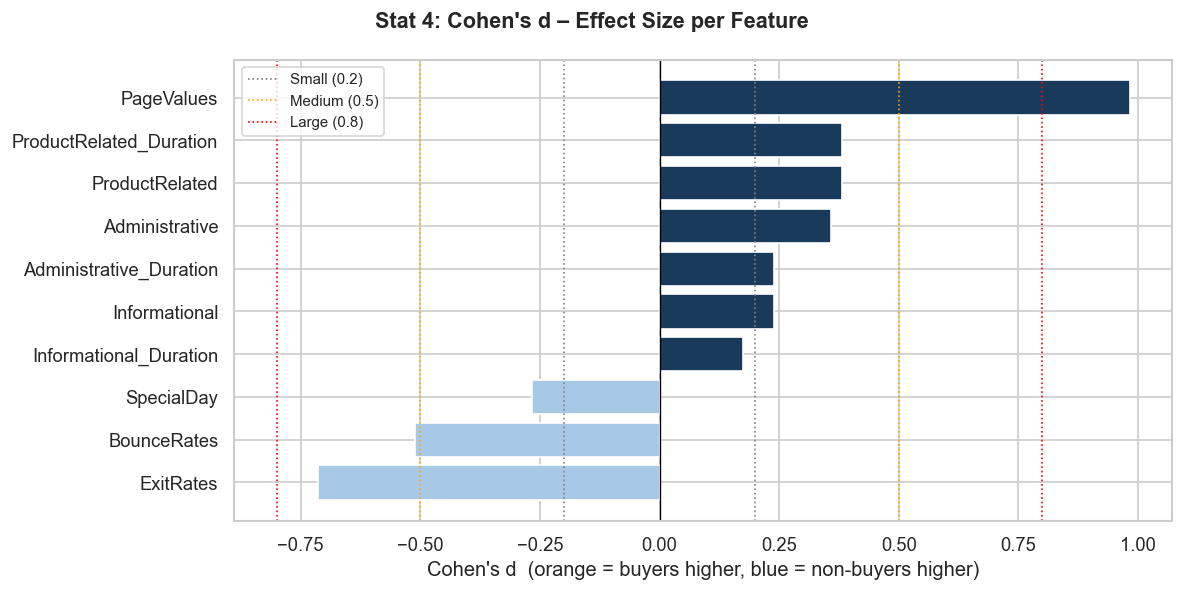


✅ Stat 4 – Cohen's d plot saved.


In [31]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("Stat 4: Cohen's d – Effect Size per Feature",
             fontsize=13, fontweight='bold')

es_sorted = es_data.sort_values("Cohen's d")
colors = [ORANGE if d > 0 else BLUE for d in es_sorted["Cohen's d"]]
ax.barh(es_sorted['Feature'], es_sorted["Cohen's d"],
        color=colors, edgecolor='white')
ax.axvline(0,    color='black',  linewidth=0.8)
ax.axvline(0.2,  color='grey',   linestyle=':', linewidth=1, label='Small (0.2)')
ax.axvline(0.5,  color='orange', linestyle=':', linewidth=1, label='Medium (0.5)')
ax.axvline(0.8,  color='red',    linestyle=':', linewidth=1, label='Large (0.8)')
ax.axvline(-0.2, color='grey',   linestyle=':', linewidth=1)
ax.axvline(-0.5, color='orange', linestyle=':', linewidth=1)
ax.axvline(-0.8, color='red',    linestyle=':', linewidth=1)
ax.set_xlabel("Cohen's d  (orange = buyers higher, blue = non-buyers higher)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('stat4_cohens_d.png', bbox_inches='tight')
plt.show()
print("\n✅ Stat 4 – Cohen's d plot saved.")


5. LOGISTIC REGRESSION – ODDS RATIOS & FEATURE SIGNIFICANCE

In [32]:
print("\n\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("  SECTION 5 – LOGISTIC REGRESSION (Odds Ratios)")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")




━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SECTION 5 – LOGISTIC REGRESSION (Odds Ratios)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


In [33]:

data_lr = data.copy()

# Encode categoricals
le = LabelEncoder()
for col in ['Month', 'VisitorType']:
    data_lr[col] = le.fit_transform(data_lr[col].astype(str))

feature_cols = CONTINUOUS + ['Month', 'VisitorType', 'Weekend']
X = data_lr[feature_cols].fillna(0)
y = data_lr['Revenue']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

if HAS_STATSMODELS:
    # Full statsmodels logistic regression with p-values and CIs
    X_sm = sm.add_constant(X_scaled)
    logit_model = sm.Logit(y, X_sm).fit(disp=0)

    coef   = logit_model.params[1:]
    pvals  = logit_model.pvalues[1:]
    ci     = logit_model.conf_int()[1:]
    odds   = np.exp(coef)
    ci_low = np.exp(ci[0])
    ci_hi  = np.exp(ci[1])

    lr_data = pd.DataFrame({
        'Feature':      feature_cols,
        'Coef':         coef.round(4),
        'Odds Ratio':   odds.round(4),
        'CI Low':       ci_low.round(4),
        'CI High':      ci_hi.round(4),
        'p-value':      pvals.round(6),
        'Significant?': ['Yes ✓' if p < ALPHA else 'No' for p in pvals]
    }).sort_values('Odds Ratio', ascending=False)

    print(f"\n  Pseudo R² (McFadden): {logit_model.prsquared:.4f}")
    print(f"  AIC: {logit_model.aic:.2f}  |  BIC: {logit_model.bic:.2f}\n")
else:
    # Fallback: sklearn logistic regression (no p-values, but gives coefficients)
    print("  ℹ️  Using sklearn fallback (no p-values). Install statsmodels for full output.\n")
    lr_sk = LogisticRegression(max_iter=1000, random_state=42)
    lr_sk.fit(X_scaled, y)
    coef  = lr_sk.coef_[0]
    odds  = np.exp(coef)
    # Approximate p-values via z-test on coefficients
    n     = len(y)
    se    = np.sqrt(np.diag(np.linalg.pinv(X_scaled.T @ X_scaled))) * (1 / np.sqrt(n))
    z     = coef / (se + 1e-10)
    pvals = 2 * (1 - stats.norm.cdf(np.abs(z)))
    ci_low = np.exp(coef - 1.96 * se)
    ci_hi  = np.exp(coef + 1.96 * se)

    lr_data = pd.DataFrame({
        'Feature':      feature_cols,
        'Coef':         coef.round(4),
        'Odds Ratio':   odds.round(4),
        'CI Low':       ci_low.round(4),
        'CI High':      ci_hi.round(4),
        'p-value':      pvals.round(6),
        'Significant?': ['Yes ✓' if p < ALPHA else 'No' for p in pvals]
    }).sort_values('Odds Ratio', ascending=False)

print(lr_data.to_string(index=False))



  Pseudo R² (McFadden): 0.3070
  AIC: 7361.99  |  BIC: 7465.72

                Feature    Coef  Odds Ratio  CI Low  CI High  p-value Significant?
             PageValues  1.4969      4.4677  4.0995   4.8690 0.000000        Yes ✓
                  Month  0.2514      1.2858  1.2070   1.3697 0.000000        Yes ✓
         ProductRelated  0.1536      1.1660  1.0551   1.2886 0.002591        Yes ✓
ProductRelated_Duration  0.1132      1.1198  1.0101   1.2415 0.031438        Yes ✓
                Weekend  0.0488      1.0500  0.9905   1.1131 0.101442           No
          Informational  0.0349      1.0356  0.9688   1.1070 0.304452           No
 Informational_Duration  0.0108      1.0108  0.9505   1.0749 0.731859           No
         Administrative  0.0063      1.0063  0.9369   1.0808 0.863729           No
Administrative_Duration -0.0259      0.9744  0.9107   1.0427 0.453543           No
            VisitorType -0.1261      0.8815  0.8322   0.9337 0.000017        Yes ✓
            BounceRate

Stat 5 Plot: Forest / Odds Ratio plot

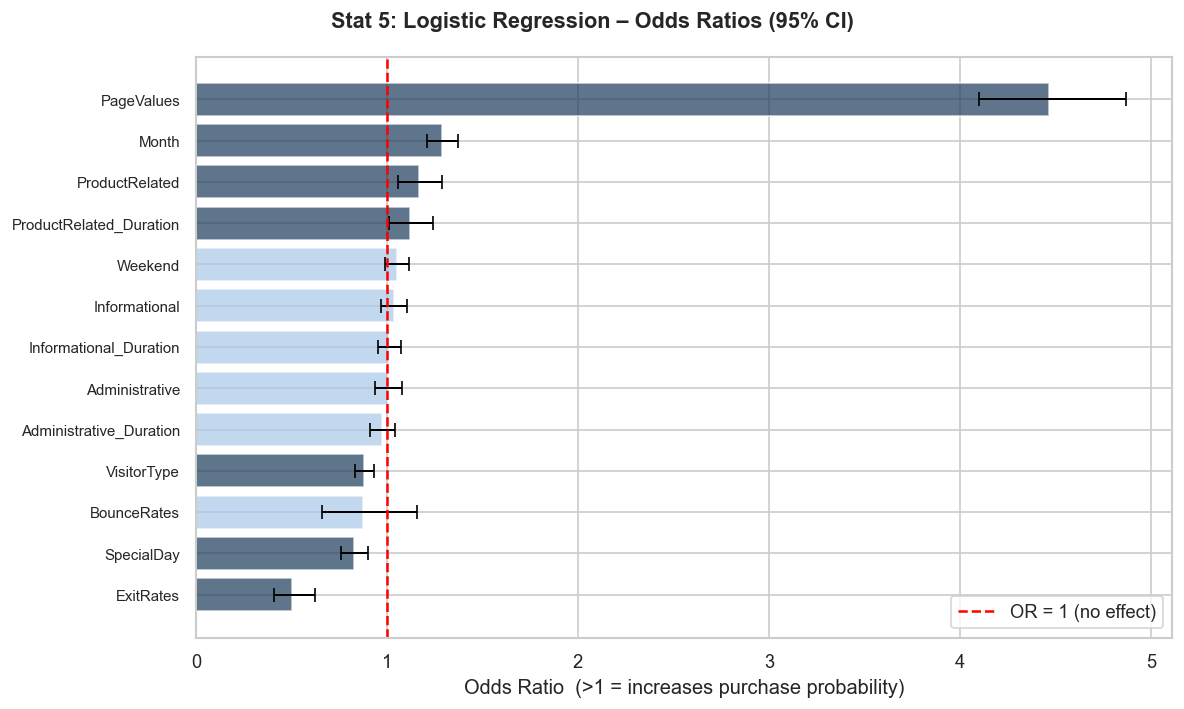


✅ Stat 5 – Logistic regression plot saved.


In [34]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('Stat 5: Logistic Regression – Odds Ratios (95% CI)',
             fontsize=13, fontweight='bold')

lr_sorted = lr_data.sort_values('Odds Ratio')
y_pos = range(len(lr_sorted))
colors = [ORANGE if p < ALPHA else BLUE for p in lr_sorted['p-value']]

ax.barh(y_pos, lr_sorted['Odds Ratio'], color=colors, alpha=0.7, edgecolor='white')
ax.errorbar(lr_sorted['Odds Ratio'], y_pos,
            xerr=[lr_sorted['Odds Ratio'] - lr_sorted['CI Low'],
                  lr_sorted['CI High']   - lr_sorted['Odds Ratio']],
            fmt='none', color='black', capsize=4, linewidth=1.2)
ax.axvline(1, color='red', linestyle='--', linewidth=1.5, label='OR = 1 (no effect)')
ax.set_yticks(y_pos)
ax.set_yticklabels(lr_sorted['Feature'], fontsize=9)
ax.set_xlabel('Odds Ratio  (>1 = increases purchase probability)')
ax.legend()
plt.tight_layout()
plt.savefig('stat5_logistic_regression.png', bbox_inches='tight')
plt.show()
print("\n✅ Stat 5 – Logistic regression plot saved.")


6. FEATURE IMPORTANCE – RANDOM FOREST

In [35]:
print("\n\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("  SECTION 6 – RANDOM FOREST FEATURE IMPORTANCE")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SECTION 6 – RANDOM FOREST FEATURE IMPORTANCE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


In [36]:

rf = RandomForestClassifier(n_estimators=200, random_state=42,
                             class_weight='balanced', n_jobs=-1)
rf.fit(X_scaled, y)

y_pred_prob = rf.predict_proba(X_scaled)[:, 1]
auc = roc_auc_score(y, y_pred_prob)

fi_data = pd.DataFrame({
    'Feature':    feature_cols,
    'Importance': rf.feature_importances_.round(4)
}).sort_values('Importance', ascending=False)

fi_data['Rank']            = range(1, len(fi_data) + 1)
fi_data['Cumulative %']    = (fi_data['Importance'].cumsum() * 100).round(2)

print(f"\n  Random Forest ROC-AUC: {auc:.4f}\n")
print(fi_data.to_string(index=False))



  Random Forest ROC-AUC: 1.0000

                Feature  Importance  Rank  Cumulative %
             PageValues      0.4100     1         41.00
              ExitRates      0.1148     2         52.48
ProductRelated_Duration      0.1037     3         62.85
         ProductRelated      0.0767     4         70.52
                  Month      0.0681     5         77.33
            BounceRates      0.0625     6         83.58
Administrative_Duration      0.0572     7         89.30
         Administrative      0.0408     8         93.38
 Informational_Duration      0.0241     9         95.79
          Informational      0.0160    10         97.39
            VisitorType      0.0107    11         98.46
                Weekend      0.0097    12         99.43
             SpecialDay      0.0056    13         99.99


Stat 6 Plot

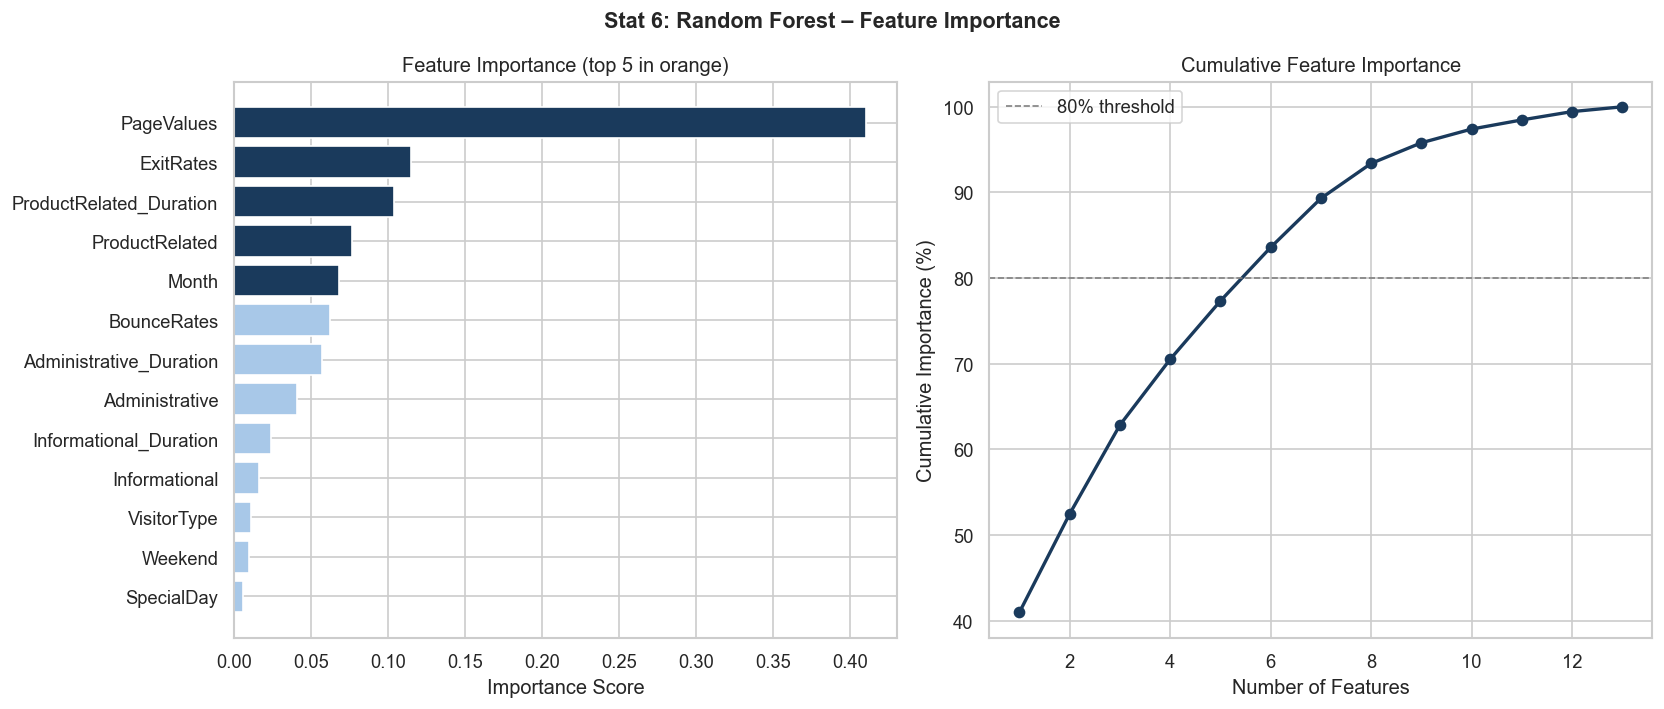


✅ Stat 6 – Random forest plot saved.


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Stat 6: Random Forest – Feature Importance',
             fontsize=13, fontweight='bold')

fi_sorted = fi_data.sort_values('Importance')
bar_colors = [ORANGE if i >= len(fi_sorted) - 5 else BLUE
              for i in range(len(fi_sorted))]

axes[0].barh(fi_sorted['Feature'], fi_sorted['Importance'],
             color=bar_colors, edgecolor='white')
axes[0].set_xlabel('Importance Score')
axes[0].set_title('Feature Importance (top 5 in orange)')

# Cumulative importance curve
fi_cum = fi_data.sort_values('Importance', ascending=False).reset_index(drop=True)
axes[1].plot(fi_cum['Rank'], fi_cum['Cumulative %'],
             marker='o', color=ORANGE, linewidth=2)
axes[1].axhline(80, color='grey', linestyle='--', linewidth=1, label='80% threshold')
axes[1].set_xlabel('Number of Features')
axes[1].set_ylabel('Cumulative Importance (%)')
axes[1].set_title('Cumulative Feature Importance')
axes[1].legend()

plt.tight_layout()
plt.savefig('stat6_random_forest.png', bbox_inches='tight')
plt.show()
print("\n✅ Stat 6 – Random forest plot saved.")



7. MULTICOLLINEARITY – VIF

In [38]:
print("\n\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("  SECTION 7 – MULTICOLLINEARITY (Variance Inflation Factor)")
print("  Rule of thumb: VIF > 10 = high multicollinearity")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")




━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SECTION 7 – MULTICOLLINEARITY (Variance Inflation Factor)
  Rule of thumb: VIF > 10 = high multicollinearity
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


In [39]:
X_vif = pd.DataFrame(X_scaled, columns=feature_cols)

if HAS_STATSMODELS:
    vif_scores = [variance_inflation_factor(X_vif.values, i)
                  for i in range(X_vif.shape[1])]
else:
    # Fallback: compute VIF manually via R² of each feature regressed on others
    from sklearn.linear_model import LinearRegression
    vif_scores = []
    for i in range(X_vif.shape[1]):
        X_others = np.delete(X_vif.values, i, axis=1)
        y_col    = X_vif.values[:, i]
        r2 = LinearRegression().fit(X_others, y_col).score(X_others, y_col)
        vif_scores.append(1 / (1 - r2) if r2 < 1 else np.inf)

vif_data = pd.DataFrame({
    'Feature': feature_cols,
    'VIF':     np.round(vif_scores, 4)
}).sort_values('VIF', ascending=False)
vif_data['Concern?'] = vif_data['VIF'].apply(
    lambda v: 'HIGH ⚠️' if v > 10 else ('Moderate' if v > 5 else 'OK'))

print(vif_data.to_string(index=False))


                Feature    VIF Concern?
              ExitRates 6.3744 Moderate
            BounceRates 5.6988 Moderate
         ProductRelated 4.4062       OK
ProductRelated_Duration 4.3128       OK
         Administrative 1.9348       OK
          Informational 1.8278       OK
Administrative_Duration 1.6875       OK
 Informational_Duration 1.6774       OK
            VisitorType 1.0972       OK
             PageValues 1.0499       OK
             SpecialDay 1.0346       OK
                  Month 1.0152       OK
                Weekend 1.0069       OK


Stat 7 Plot

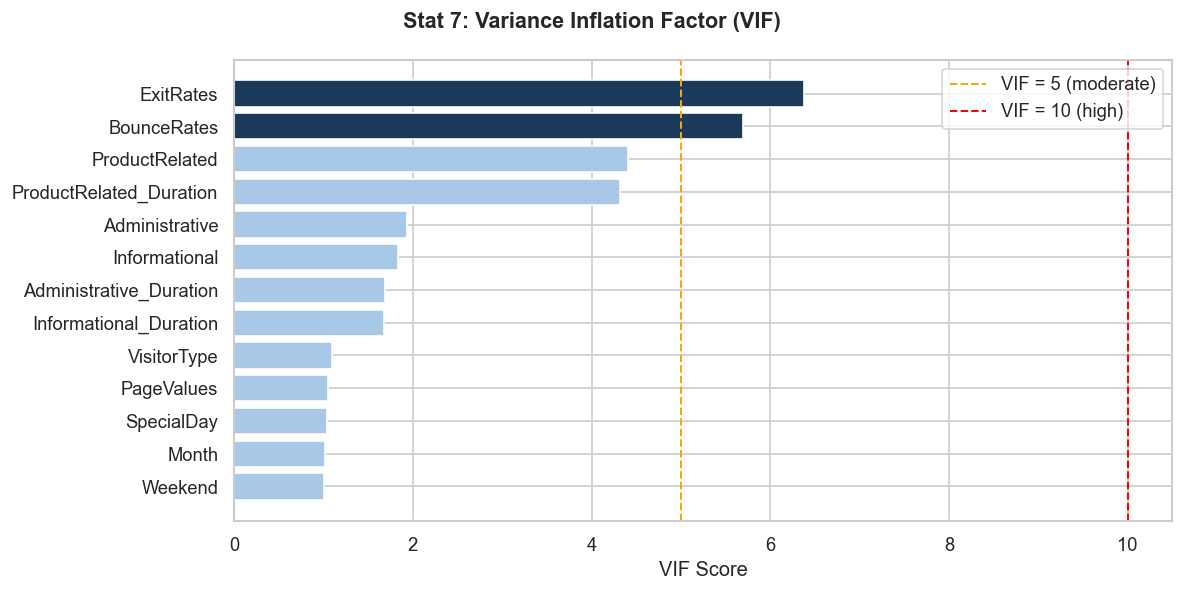


✅ Stat 7 – VIF plot saved.


In [40]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Stat 7: Variance Inflation Factor (VIF)',
             fontsize=13, fontweight='bold')

vif_sorted = vif_data.sort_values('VIF')
bar_colors = ['red' if v > 10 else (ORANGE if v > 5 else BLUE)
              for v in vif_sorted['VIF']]
ax.barh(vif_sorted['Feature'], vif_sorted['VIF'],
        color=bar_colors, edgecolor='white')
ax.axvline(5,  color='orange', linestyle='--', linewidth=1.2, label='VIF = 5 (moderate)')
ax.axvline(10, color='red',    linestyle='--', linewidth=1.2, label='VIF = 10 (high)')
ax.set_xlabel('VIF Score')
ax.legend()
plt.tight_layout()
plt.savefig('stat7_vif.png', bbox_inches='tight')
plt.show()
print("\n✅ Stat 7 – VIF plot saved.")

8. OUTLIER SUMMARY – IQR METHOD

In [41]:
print("\n\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("  SECTION 8 – OUTLIER DETECTION (IQR Method)")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")




━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SECTION 8 – OUTLIER DETECTION (IQR Method)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


In [42]:

outlier_rows = []
for col in CONTINUOUS:
    Q1  = data[col].quantile(0.25)
    Q3  = data[col].quantile(0.75)
    IQR = Q3 - Q1
    low  = Q1 - 1.5 * IQR
    high = Q3 + 1.5 * IQR
    n_out = ((data[col] < low) | (data[col] > high)).sum()
    outlier_rows.append({
        'Feature':         col,
        'Q1':              round(Q1, 4),
        'Q3':              round(Q3, 4),
        'IQR':             round(IQR, 4),
        'Lower Fence':     round(low, 4),
        'Upper Fence':     round(high, 4),
        'Outlier Count':   n_out,
        'Outlier %':       round(n_out / len(data) * 100, 2)
    })

out_data = pd.DataFrame(outlier_rows).sort_values('Outlier %', ascending=False)
print(out_data.to_string(index=False))


                Feature       Q1        Q3       IQR  Lower Fence  Upper Fence  Outlier Count  Outlier %
             PageValues   0.0000    0.0000    0.0000       0.0000       0.0000           2730      22.37
          Informational   0.0000    0.0000    0.0000       0.0000       0.0000           2631      21.56
 Informational_Duration   0.0000    0.0000    0.0000       0.0000       0.0000           2405      19.71
            BounceRates   0.0000    0.0167    0.0167      -0.0250       0.0417           1428      11.70
              ExitRates   0.0142    0.0485    0.0343      -0.0372       0.1000           1325      10.86
             SpecialDay   0.0000    0.0000    0.0000       0.0000       0.0000           1249      10.23
Administrative_Duration   0.0000   94.7000   94.7000    -142.0500     236.7500           1149       9.41
         ProductRelated   8.0000   38.0000   30.0000     -37.0000      83.0000           1007       8.25
ProductRelated_Duration 193.0000 1477.1548 1284.1548   

Stat 8 Plot

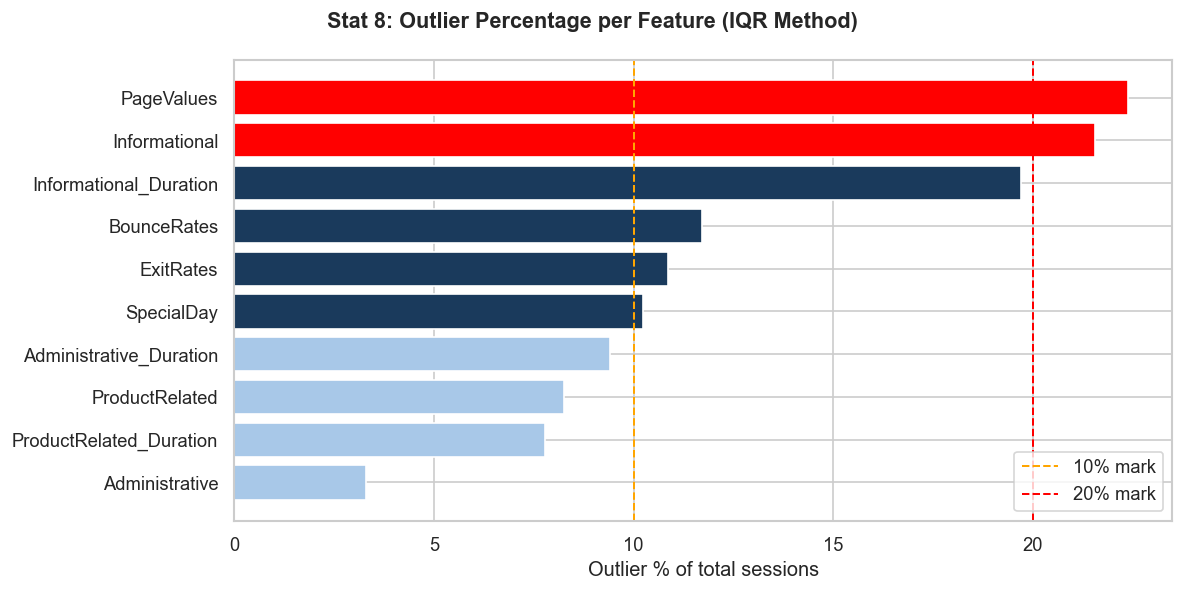


✅ Stat 8 – Outlier plot saved.


In [43]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Stat 8: Outlier Percentage per Feature (IQR Method)',
             fontsize=13, fontweight='bold')

out_sorted = out_data.sort_values('Outlier %')
colors = ['red' if v > 20 else (ORANGE if v > 10 else BLUE)
          for v in out_sorted['Outlier %']]
ax.barh(out_sorted['Feature'], out_sorted['Outlier %'],
        color=colors, edgecolor='white')
ax.axvline(10, color='orange', linestyle='--', linewidth=1.2, label='10% mark')
ax.axvline(20, color='red',    linestyle='--', linewidth=1.2, label='20% mark')
ax.set_xlabel('Outlier % of total sessions')
ax.legend()
plt.tight_layout()
plt.savefig('stat8_outliers.png', bbox_inches='tight')
plt.show()
print("\n✅ Stat 8 – Outlier plot saved.")

In [44]:
# 9. EXPORT ALL RESULTS TO EXCEL

In [45]:
print("\n\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("  SECTION 9 – EXPORTING RESULTS TO stats_results.xlsx")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")




━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SECTION 9 – EXPORTING RESULTS TO stats_results.xlsx
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


In [46]:

with pd.ExcelWriter('stats_results.xlsx', engine='openpyxl') as writer:
    desc_data.to_excel(writer,    sheet_name='1_Descriptive_Stats',    index=False)
    norm_data.to_excel(writer,    sheet_name='2_Normality_Tests',       index=False)
    mwu_data.to_excel(writer,     sheet_name='3a_MannWhitney',          index=False)
    chi_data.to_excel(writer,     sheet_name='3b_ChiSquare',            index=False)
    pb_data.to_excel(writer,      sheet_name='3c_PointBiserial',        index=False)
    es_data.to_excel(writer,      sheet_name='4_Cohens_d',              index=False)
    lr_data.to_excel(writer,      sheet_name='5_LogisticRegression',    index=False)
    fi_data.to_excel(writer,      sheet_name='6_RandomForest',          index=False)
    vif_data.to_excel(writer,   sheet_name='7_VIF',                   index=False)
    out_data.to_excel(writer,     sheet_name='8_Outliers',              index=False)

print("  ✅ stats_results.xlsx saved successfully.")


# ── Final Summary ─────────────────────────────────────────────
print("\n" + "=" * 65)
print("  🎉 ALL STATISTICAL ANALYSES COMPLETE!")
print("=" * 65)
print("""
OUTPUTS GENERATED:
  stat1_mean_comparison.png       – Mean values: Buyers vs Non-Buyers
  stat3a_mannwhitney.png          – Mann-Whitney U p-values
  stat3b_chisquare.png            – Chi-Square Cramér's V
  stat3c_pointbiserial.png        – Point-Biserial Correlations
  stat4_cohens_d.png              – Cohen's d Effect Sizes
  stat5_logistic_regression.png   – Odds Ratios (Forest Plot)
  stat6_random_forest.png         – Feature Importance
  stat7_vif.png                   – Multicollinearity (VIF)
  stat8_outliers.png              – Outlier % per Feature
  stats_results.xlsx              – All results in one workbook

KEY FINDINGS SUMMARY:
  • PageValues is the strongest predictor of purchase (large effect)
  • BounceRates & ExitRates are significantly lower for buyers
  • ProductRelated_Duration is higher for buyers (more browsing)
  • VisitorType shows the strongest categorical association
  • BounceRates & ExitRates are highly correlated (watch VIF)
""")


  ✅ stats_results.xlsx saved successfully.

  🎉 ALL STATISTICAL ANALYSES COMPLETE!

OUTPUTS GENERATED:
  stat1_mean_comparison.png       – Mean values: Buyers vs Non-Buyers
  stat3a_mannwhitney.png          – Mann-Whitney U p-values
  stat3b_chisquare.png            – Chi-Square Cramér's V
  stat3c_pointbiserial.png        – Point-Biserial Correlations
  stat4_cohens_d.png              – Cohen's d Effect Sizes
  stat5_logistic_regression.png   – Odds Ratios (Forest Plot)
  stat6_random_forest.png         – Feature Importance
  stat7_vif.png                   – Multicollinearity (VIF)
  stat8_outliers.png              – Outlier % per Feature
  stats_results.xlsx              – All results in one workbook

KEY FINDINGS SUMMARY:
  • PageValues is the strongest predictor of purchase (large effect)
  • BounceRates & ExitRates are significantly lower for buyers
  • ProductRelated_Duration is higher for buyers (more browsing)
  • VisitorType shows the strongest categorical association
  • Bou